# Standard Maxx Analysis Template


## Notes
**Overview:**   
**Rationale:**     
**Date of Experiment:**      
**Genotypes:**    
**Sex:**    
**Light Paradigm:**    
**Design:**    
**Misc:** 

## Configuration
Configuration was standard. No new or untested code.

In [1]:
#%autoreload 1
import warnings
from Arena import *
import Tracker
import TwoChoiceTracker
from ExperimentalDesign import *
from Parameters import *

# Suppress all warnings
warnings.filterwarnings('ignore')

## Parameters
Just a standard arena max, accepting the default values and a Two-Choice Tracker.

In [2]:
p=Parameters()
p.set_arena_max_values(TrackingType.TWOCHOICETRACKER)
p.print()

tracking_type: TrackingType.TWOCHOICETRACKER
fps: 8
mm_per_pixel: 0.145
speed_window_seconds: 1
micromove_speed_mm_sec: [0.2, 2]
walking_speed_mm_sec: 2
sleep_threshold_min: 5


## Read in the data

Next we will read in the data to an Arena object. The format is`Arena(ExperimentName, parameters, data_path="./")`. This will automatically calculate all relevant metrics for the tracking type in question.  

The name of the experiment and predefined parameters object are required, but _data_path_ is optional (if no data directory is specified, it defaults to the current working directory).

The following files must be present in the defined data directory :
* The DTrack experiment file, which is an excel sheet with the name '_ExperimentName.xlsx_'.
* The DTrack data files themselves, which are named '_ExperimentName_Data_1.csv_', '_ExperimentName_Data_2.csv_', etc.
* An experiment file (most of the time, definitely for a TwoChoiceTracker), which is named '_ExperimentName_Design.txt_'.

In [3]:
arena = Arena.Arena('MaxIRSetup',p,data_path='./Data/')

## Summary
Get the summary results for all trackers, including treatments, etc.   
This will copy the results to the clipboard and save the data in a file called '_ExperimentName_Summary.csv_'.   
The semicolon at the end of the command will suppress the output to this notebook.  Remove it if you want to see the results dataframe.

In [4]:
arena.summarize(copy_to_clipboard=True,write_to_csvfile=True);

Or you can also create a faceted summary if you want to separate the different phases of the experiment.   
The file name will be '_ExperimentName_Summary_Facet.csv_'.

In [5]:
arena.summarize_facet(cutoffs=(10,70),copy_to_clipboard=True,write_to_csvfile=True);

## Plotting
There are lots of cool plotting funtions.  Some are shown below.

**Facet plots:** First of PI, then Percentage, then Total Distance (in mm/min).   
Cutoffs separate the acclimaton phase from the experiment phase from the cool down phase.

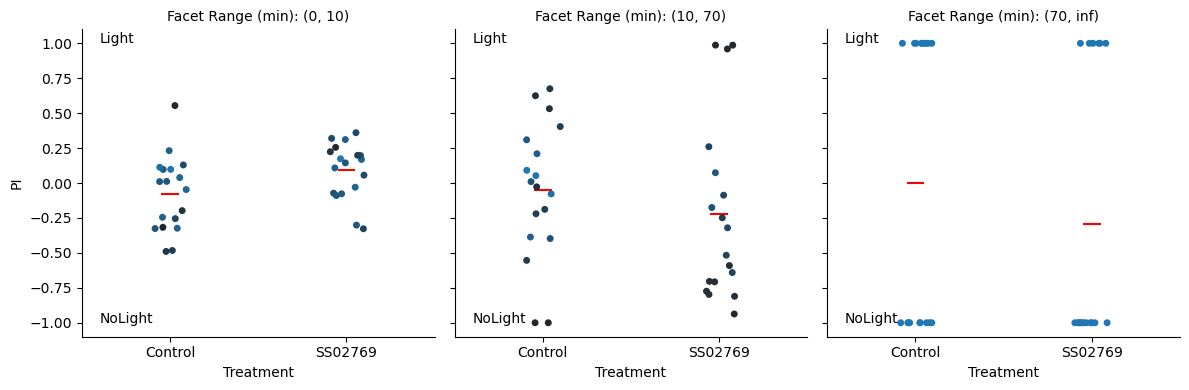

In [6]:
arena.plot_pi_facet(cutoffs=(10,70))

In [7]:
arena.run_pairwise_comparisons_facet(metric="FinalPI",cutoffs=(10,70))

############# T-Test #############
Column = FinalPI, Range Minutes = (0.00 , 10.00) 
Control vs. SS02769: T=-2.10, p=0.04280


############# T-Test #############
Column = FinalPI, Range Minutes = (10.00 , 70.00) 
Control vs. SS02769: T=0.90, p=0.37270


############# T-Test #############
Column = FinalPI, Range Minutes = (70.00 , inf) 
Control vs. SS02769: T=nan, p=nan




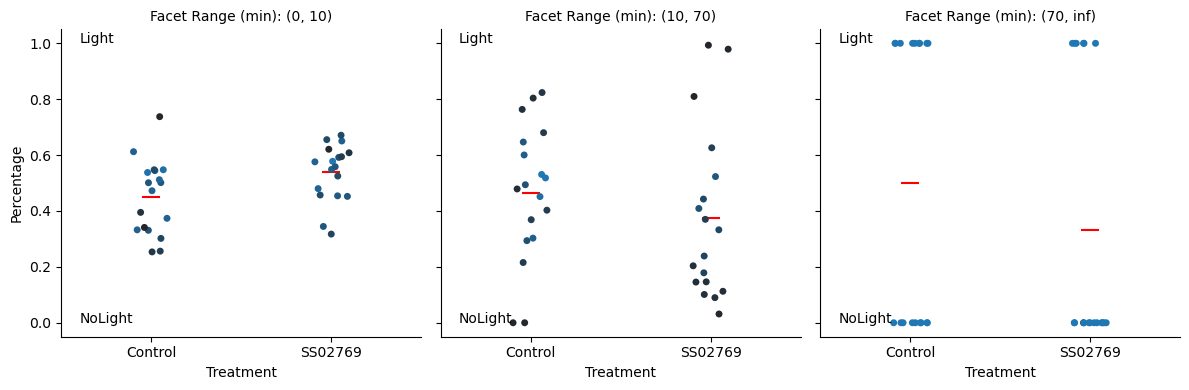

In [8]:
arena.plot_percentage_facet(cutoffs=(10,70))

In [9]:
arena.run_pairwise_comparisons_facet(metric="FinalPercentage",cutoffs=(10,70))

############# T-Test #############
Column = FinalPercentage, Range Minutes = (0.00 , 10.00) 
Control vs. SS02769: T=-2.23, p=0.03249


############# T-Test #############
Column = FinalPercentage, Range Minutes = (10.00 , 70.00) 
Control vs. SS02769: T=1.00, p=0.32628


############# T-Test #############
Column = FinalPercentage, Range Minutes = (70.00 , inf) 
Control vs. SS02769: T=1.00, p=0.32437




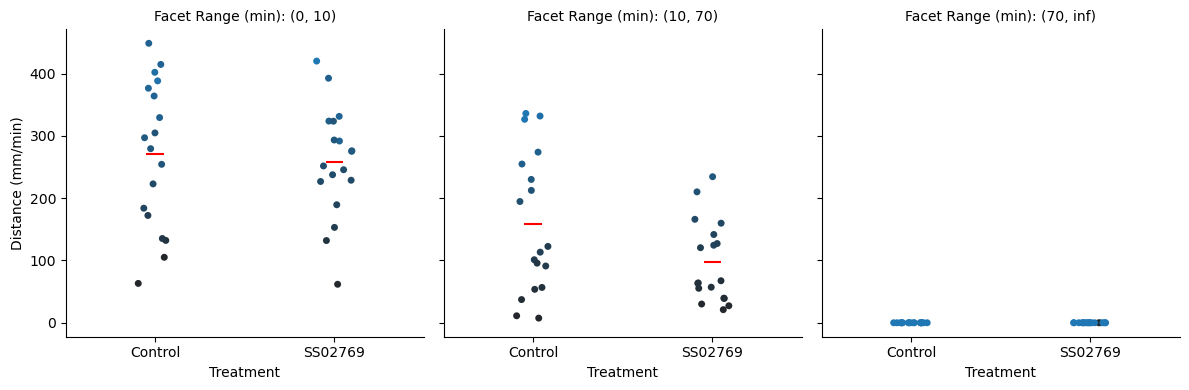

In [10]:
arena.plot_totaldistance_facet(cutoffs=(10,70))

In [11]:
arena.run_pairwise_comparisons_facet(metric="TotalDistance",cutoffs=(10,70))

############# T-Test #############
Column = TotalDistance, Range Minutes = (0.00 , 10.00) 
Control vs. SS02769: T=0.35, p=0.72841


############# T-Test #############
Column = TotalDistance, Range Minutes = (10.00 , 70.00) 
Control vs. SS02769: T=1.99, p=0.05493


############# T-Test #############
Column = TotalDistance, Range Minutes = (70.00 , inf) 
Control vs. SS02769: T=nan, p=nan




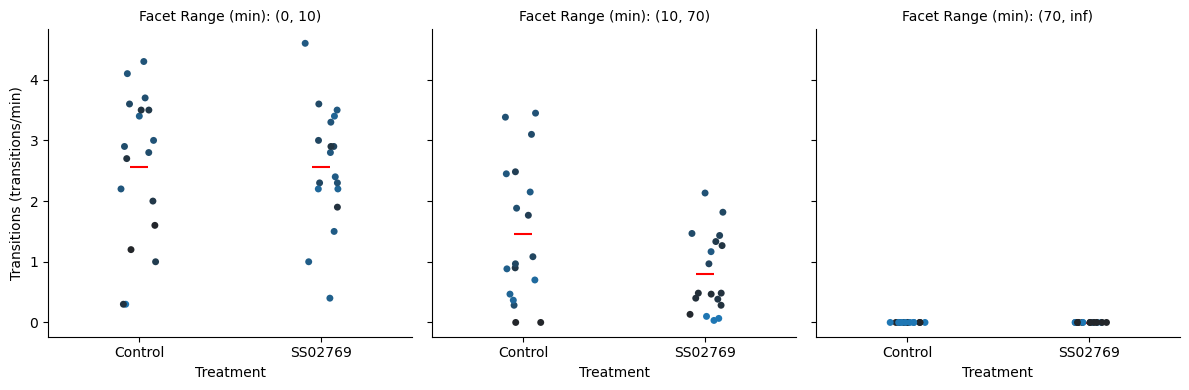

In [12]:
arena.plot_transitions_facet(cutoffs=(10,70))

In [13]:
arena.run_pairwise_comparisons_facet(metric="Transitions",cutoffs=(10,70))

############# T-Test #############
Column = Transitions, Range Minutes = (0.00 , 10.00) 
Control vs. SS02769: T=-0.01, p=0.98832


############# T-Test #############
Column = Transitions, Range Minutes = (10.00 , 70.00) 
Control vs. SS02769: T=2.12, p=0.04171


############# T-Test #############
Column = Transitions, Range Minutes = (70.00 , inf) 
Control vs. SS02769: T=1.00, p=0.32437




**Tracker plots:** These show, for each tracker individually, the progression of PI and Percentage showing cumulative values and time-dependent values

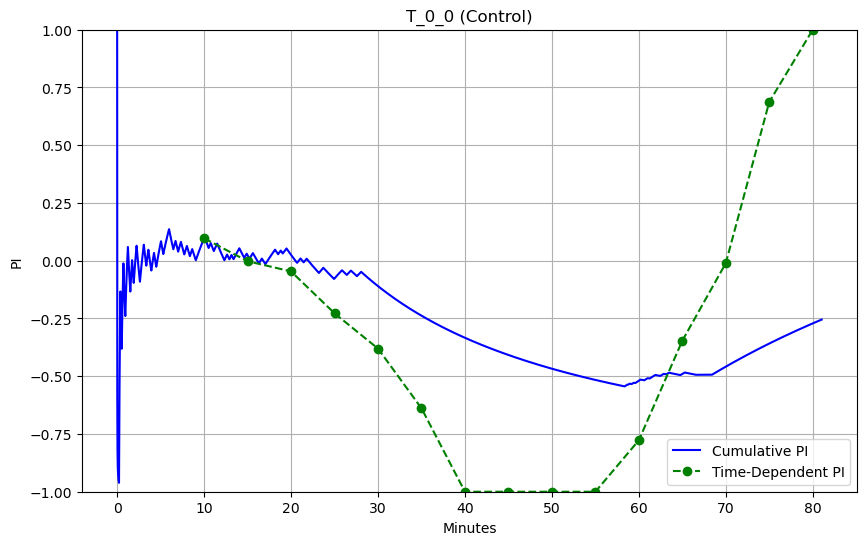

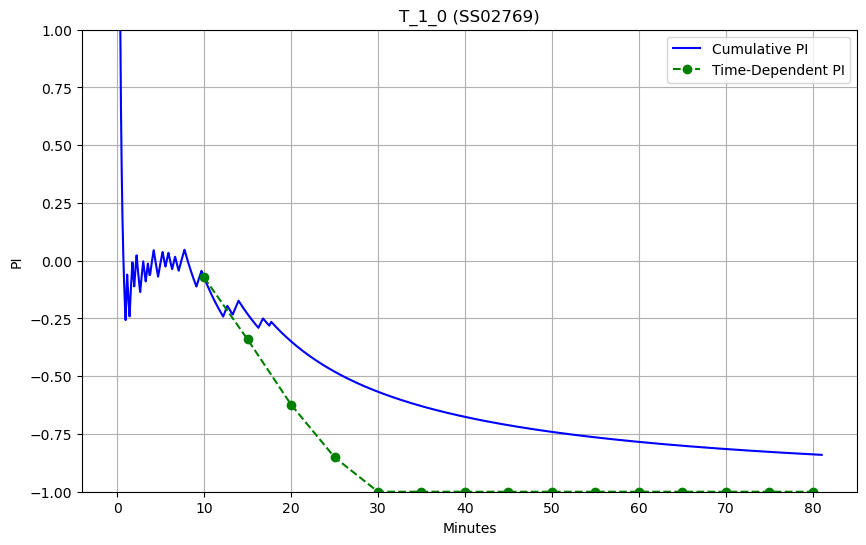

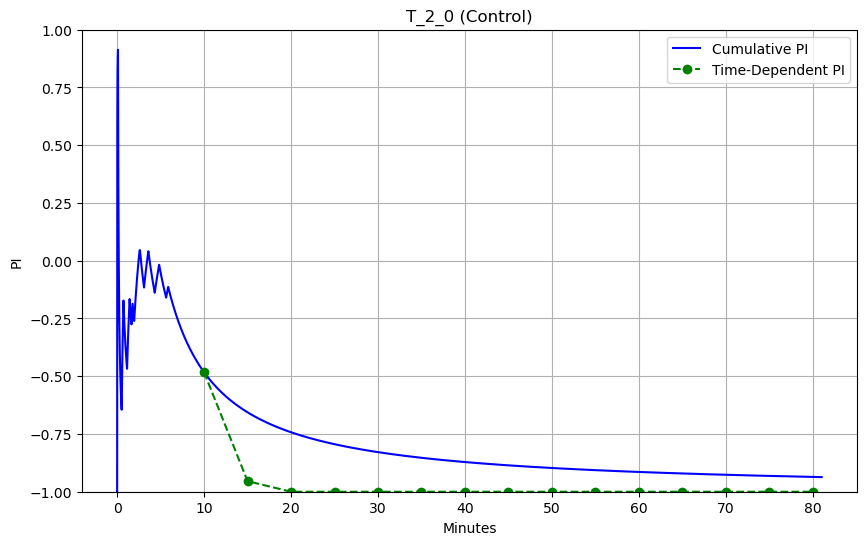

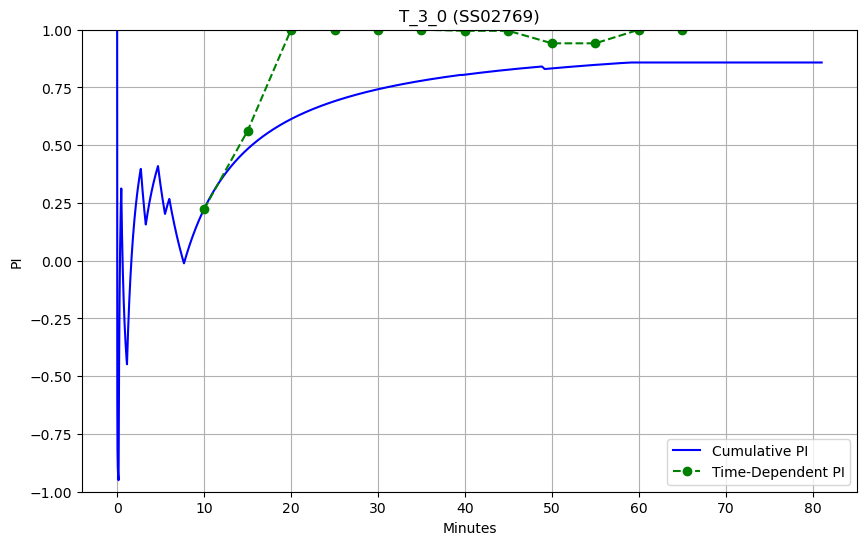

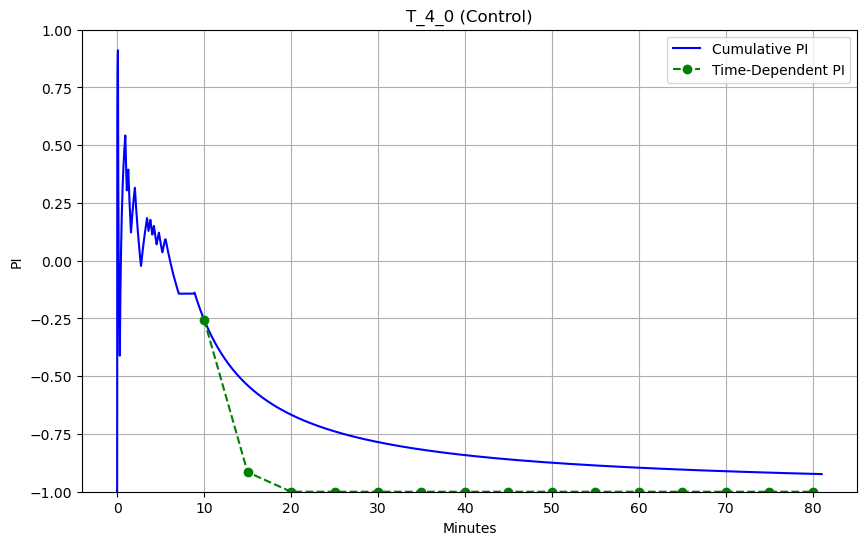

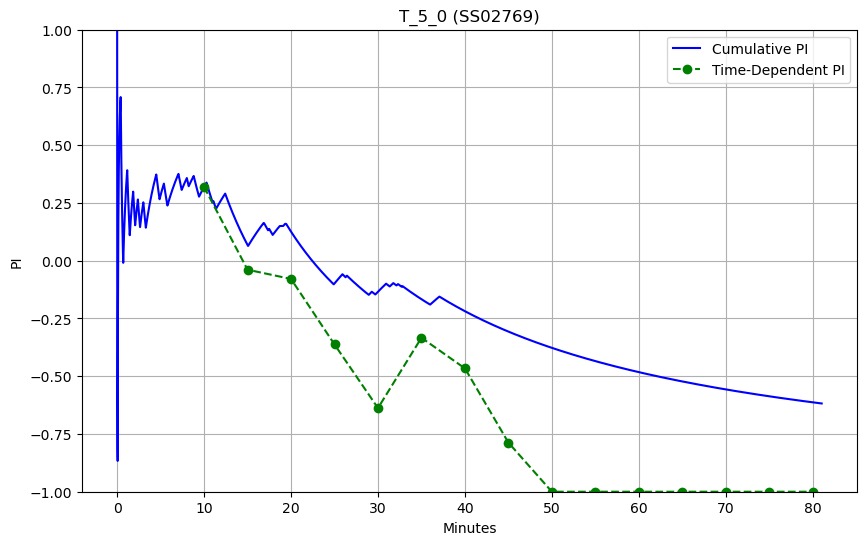

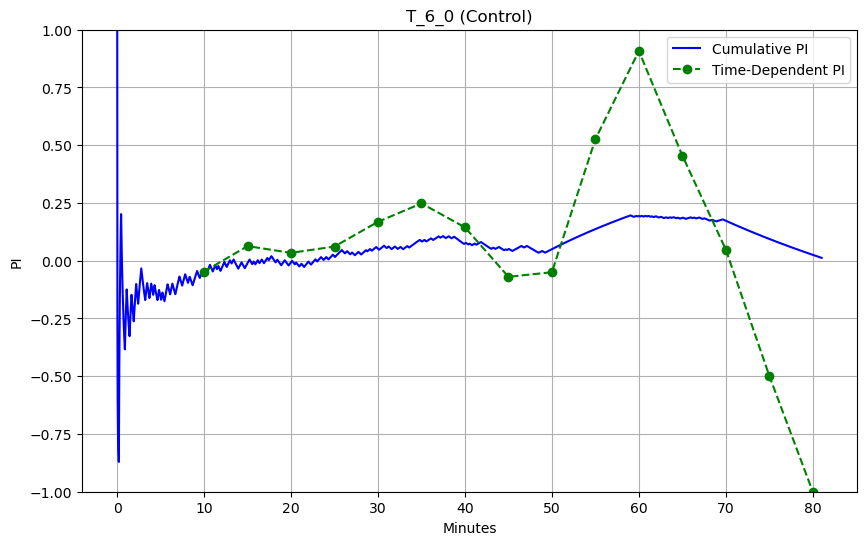

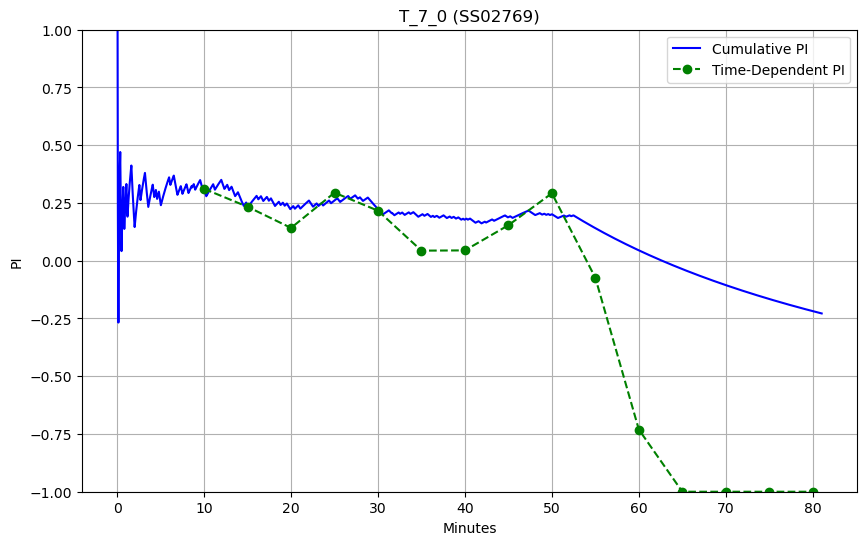

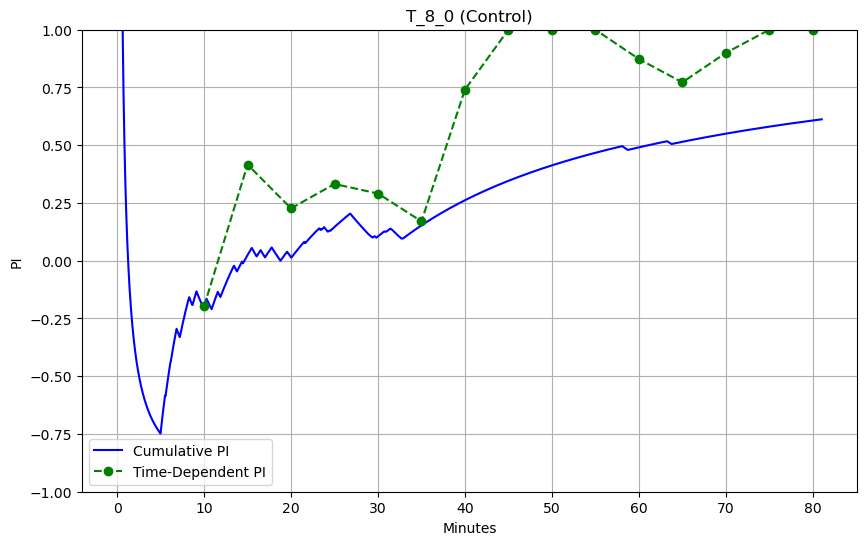

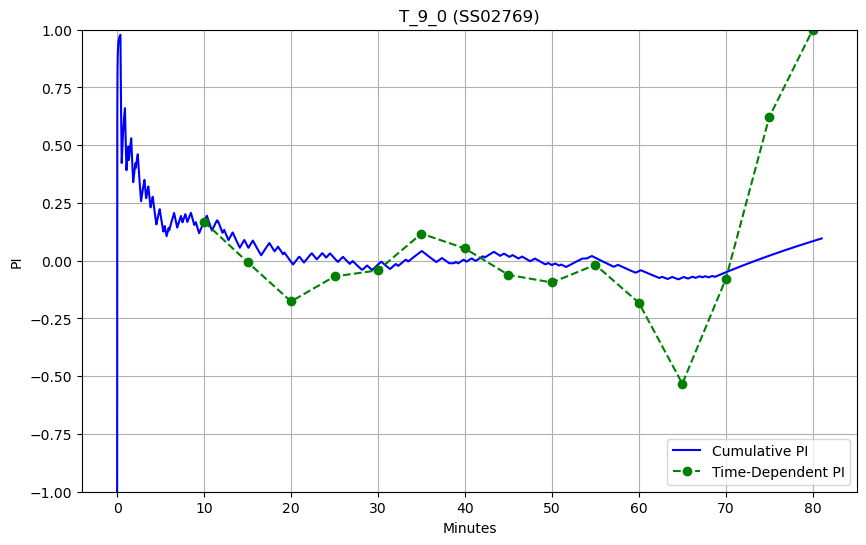

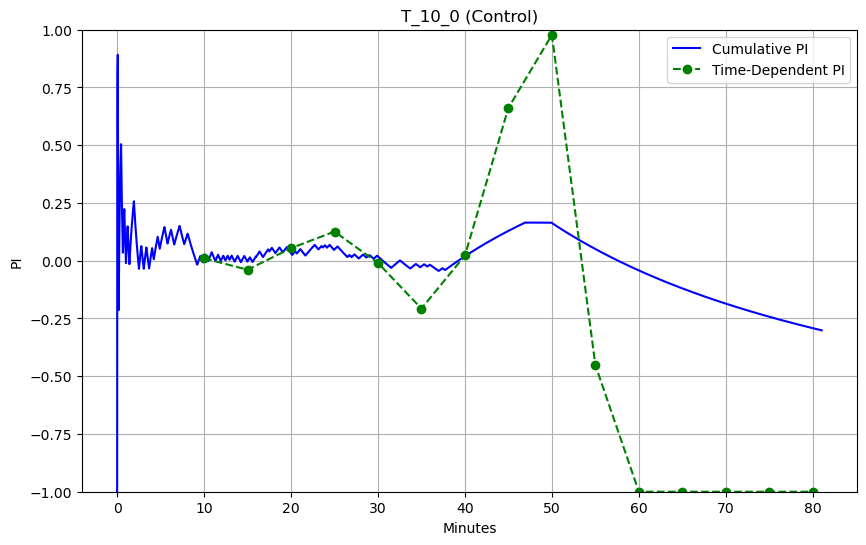

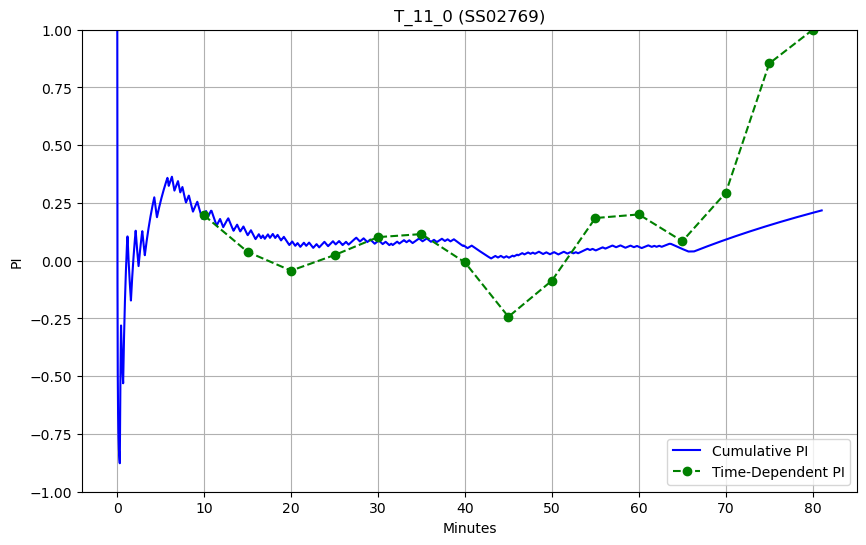

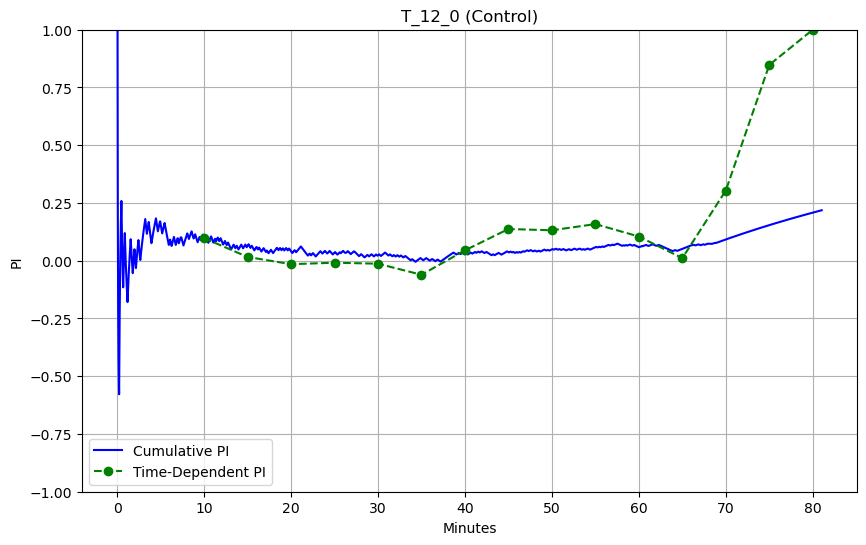

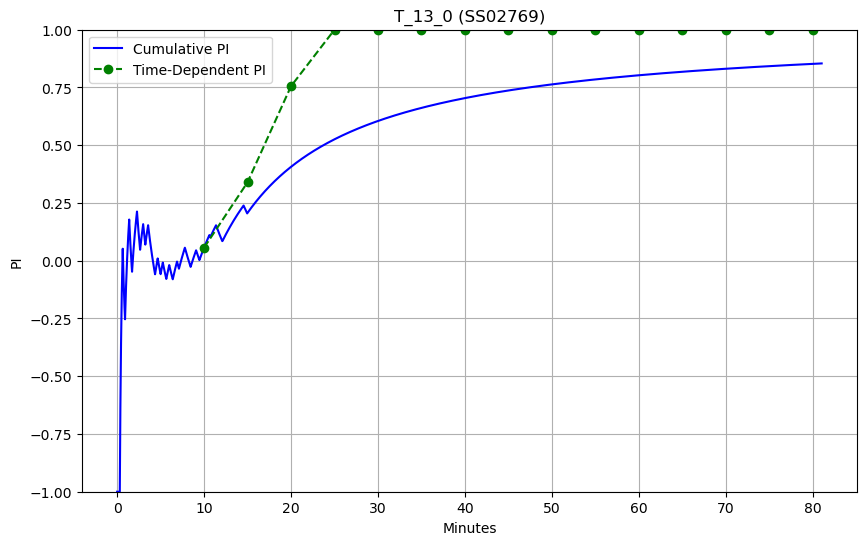

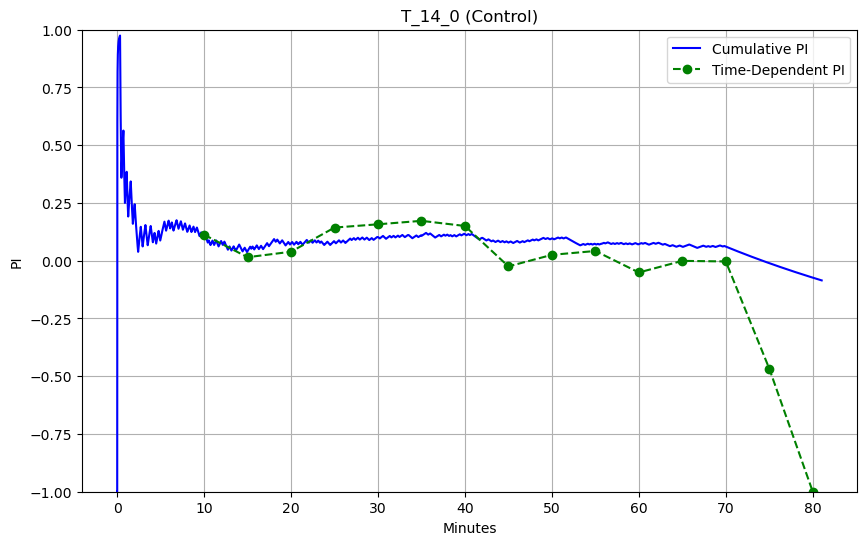

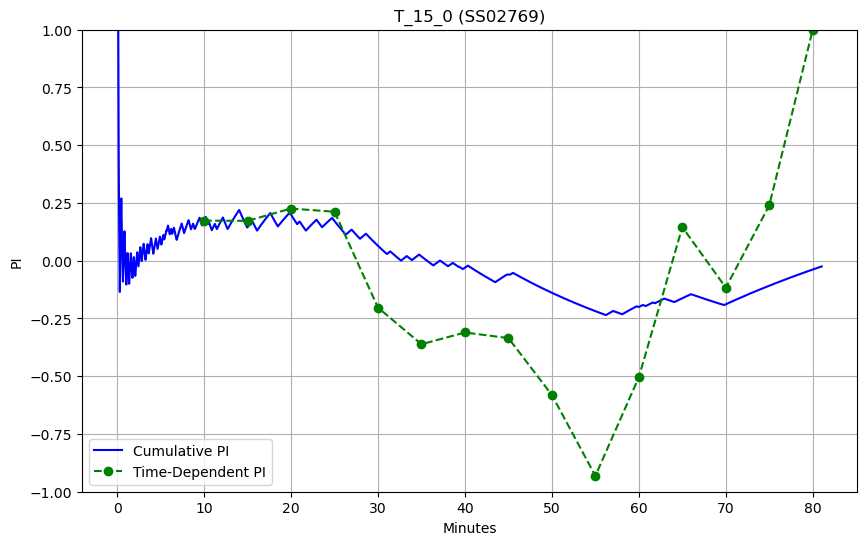

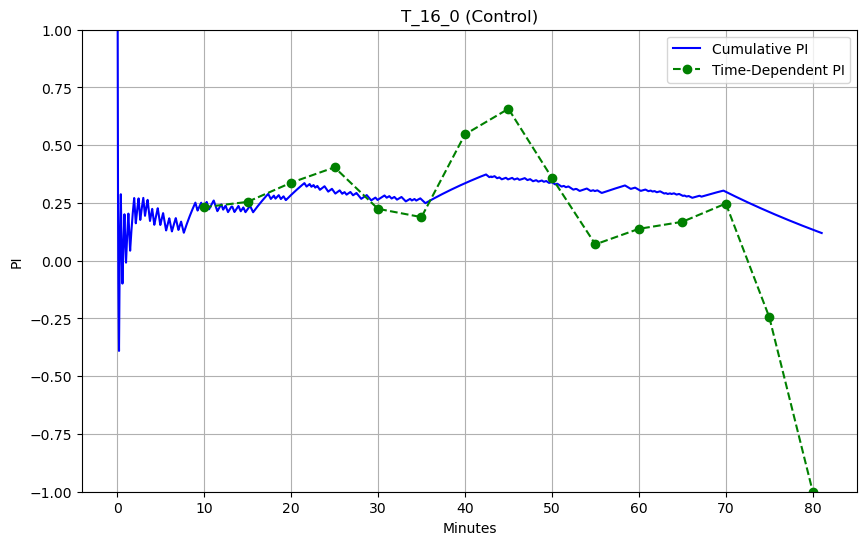

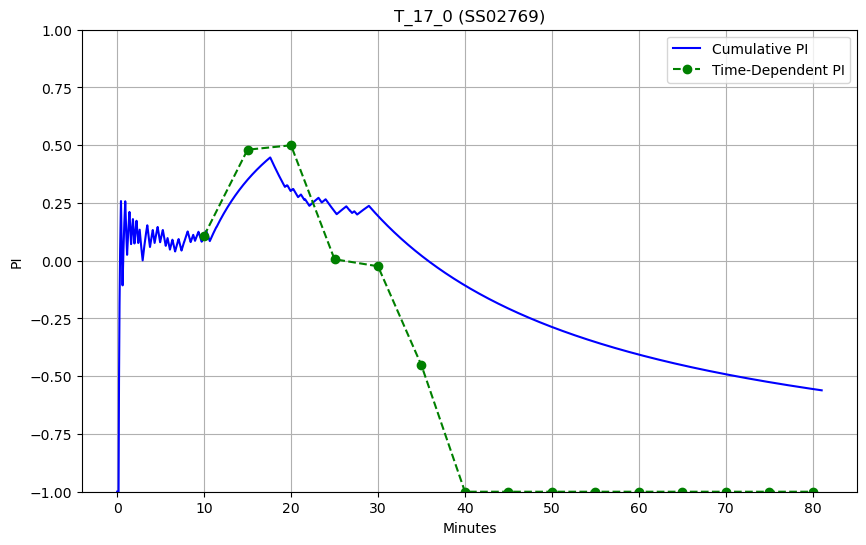

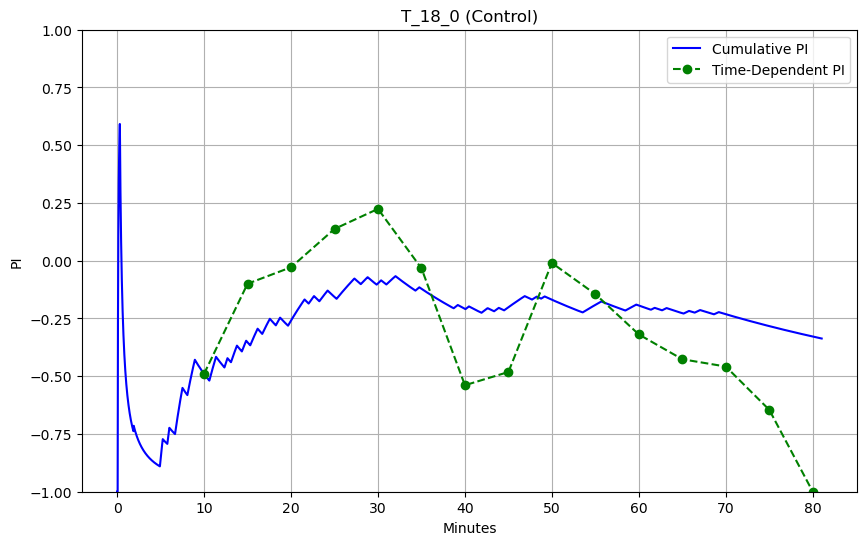

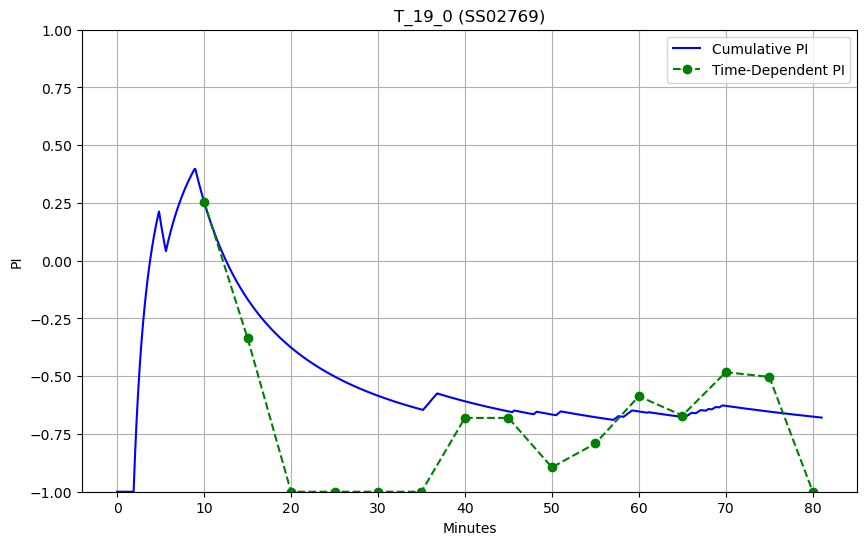

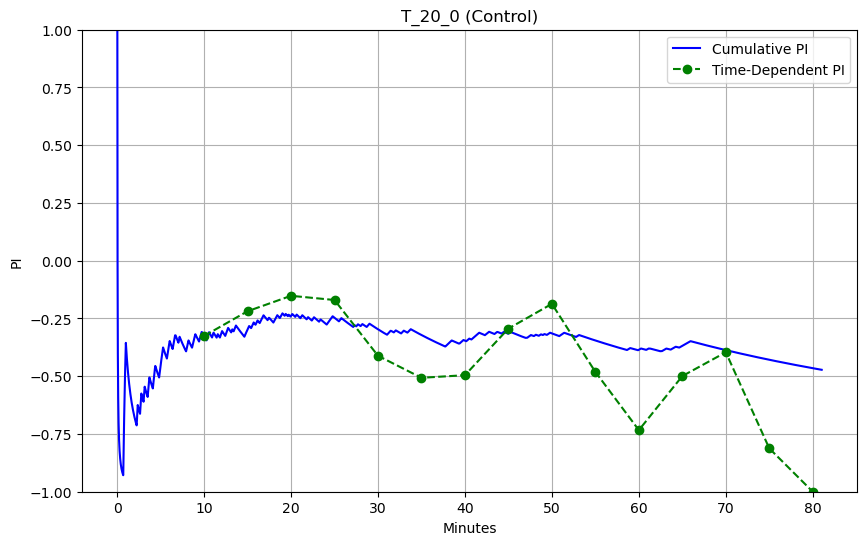

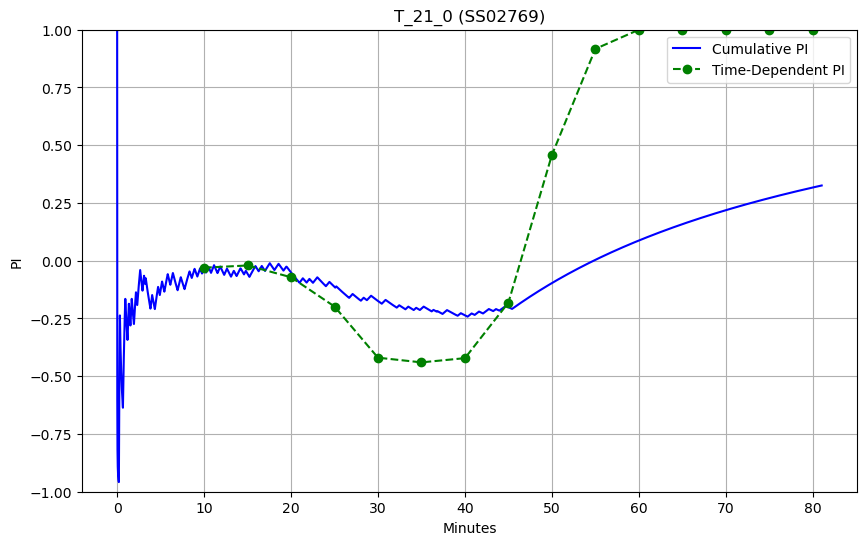

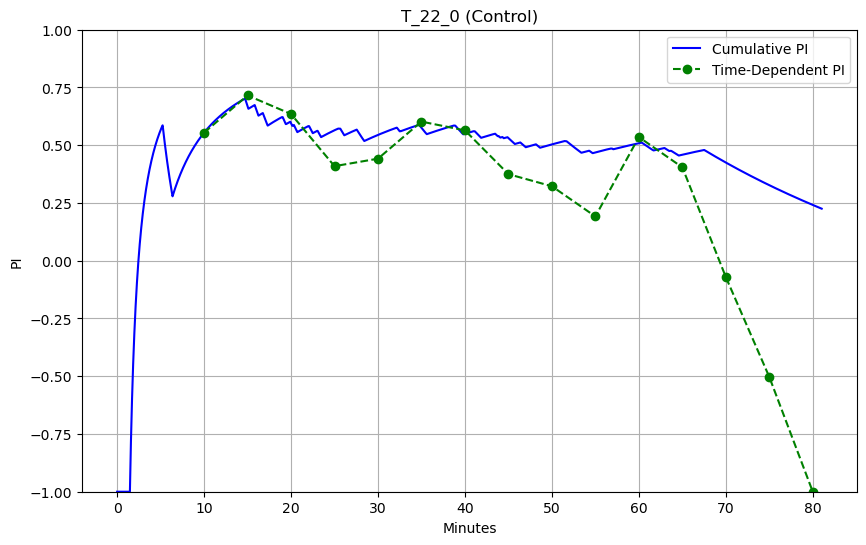

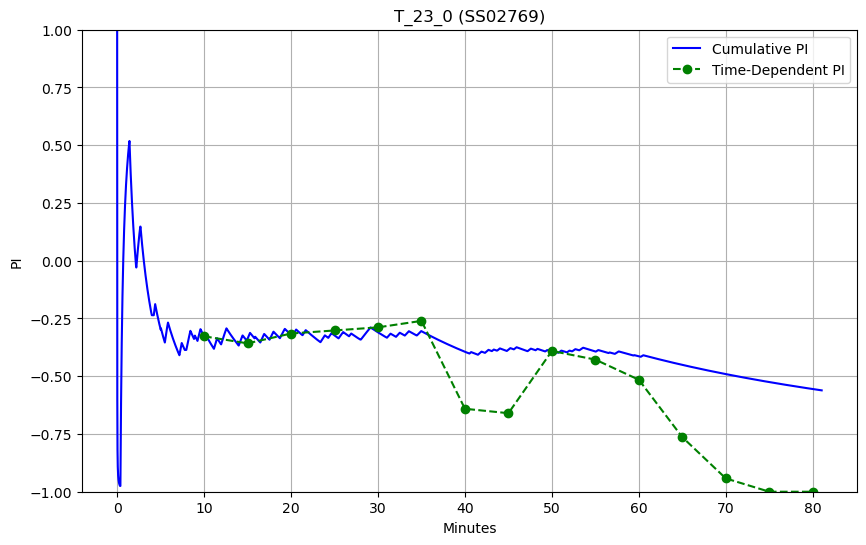

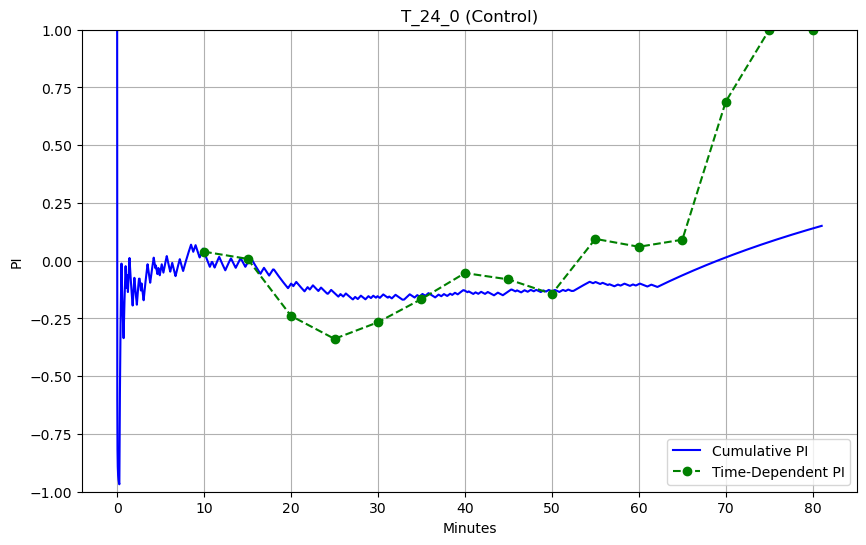

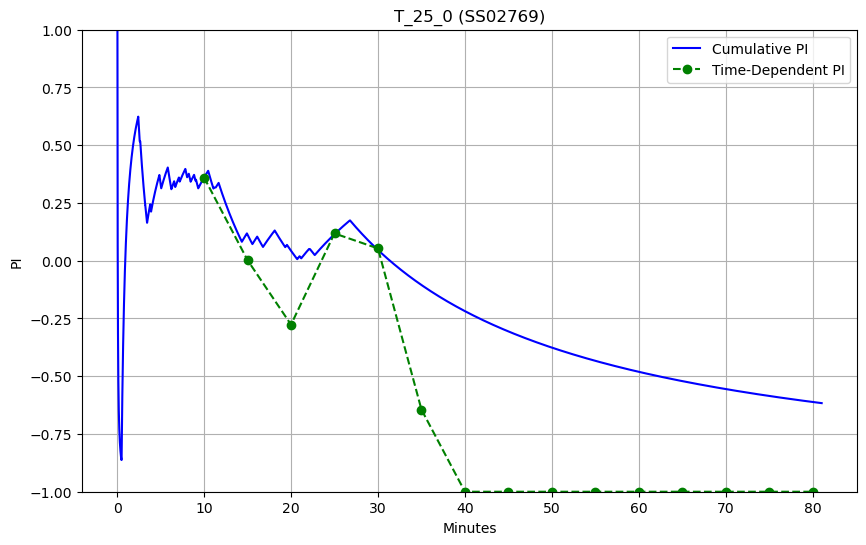

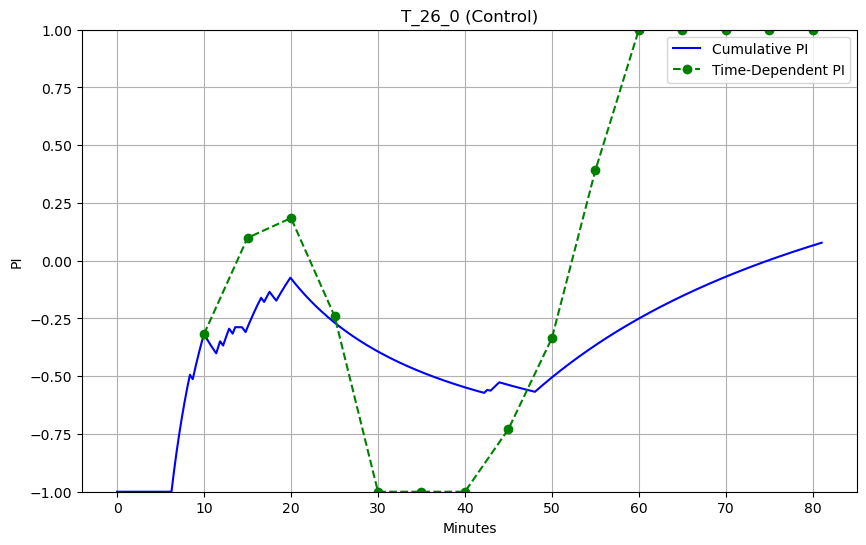

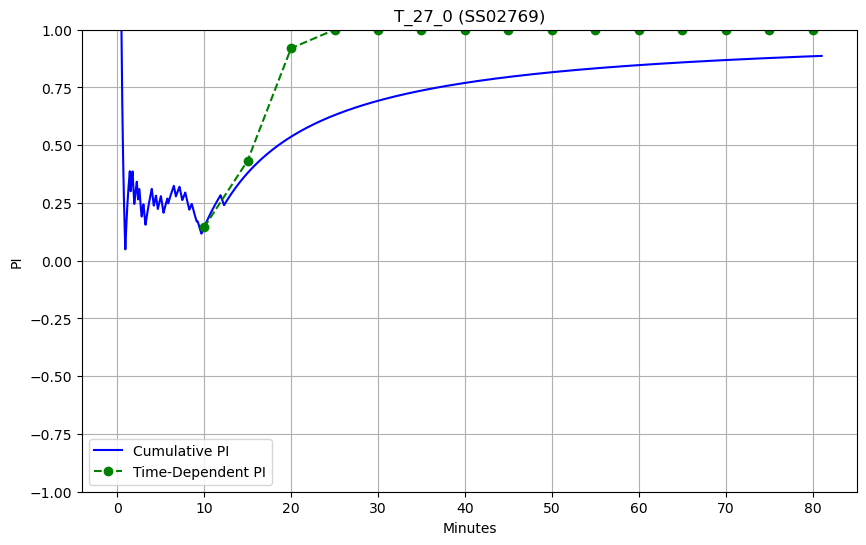

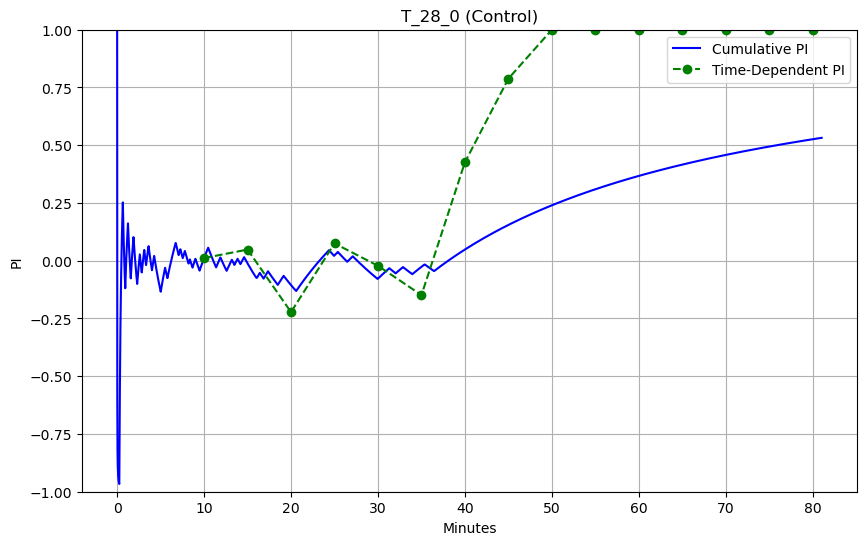

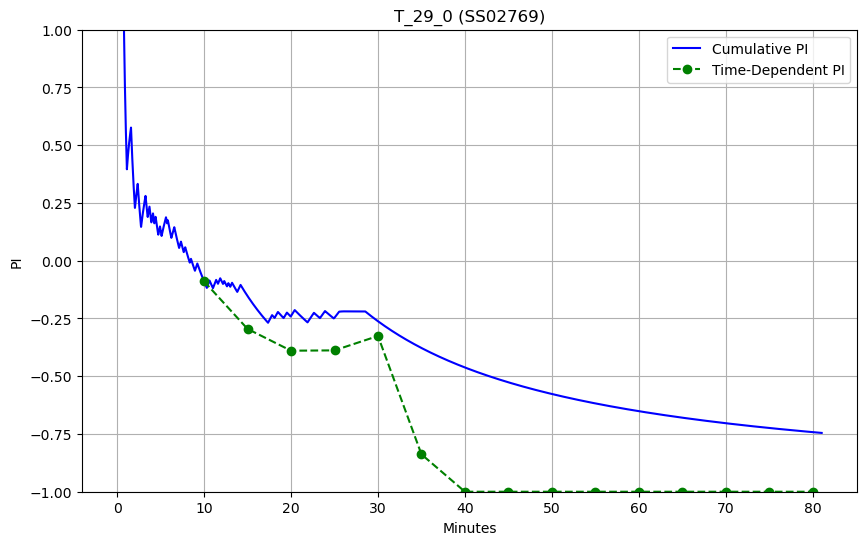

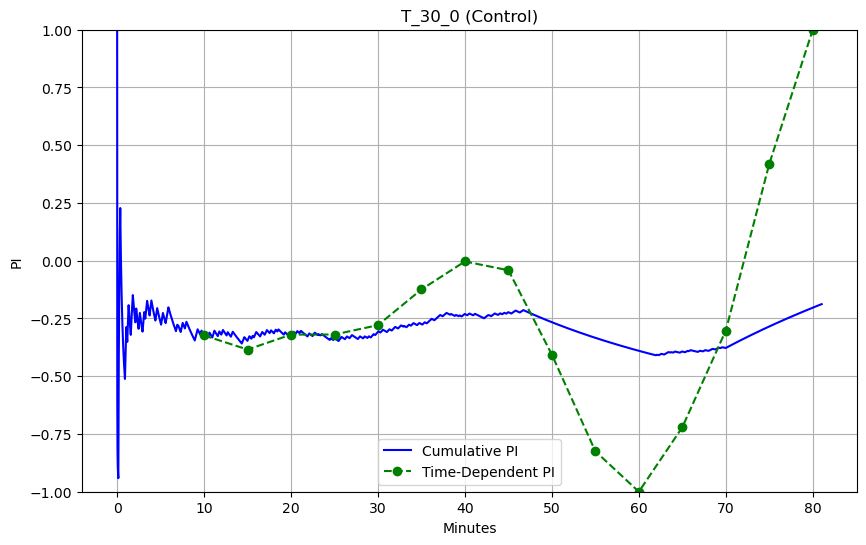

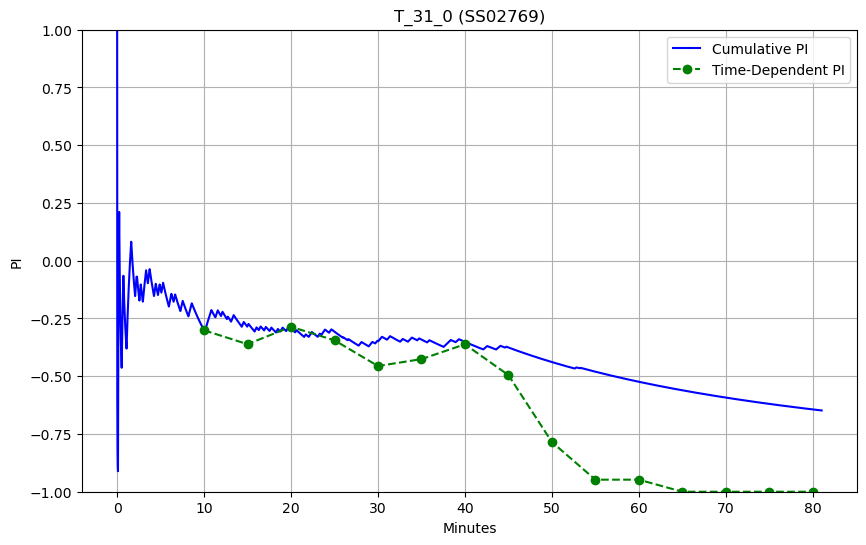

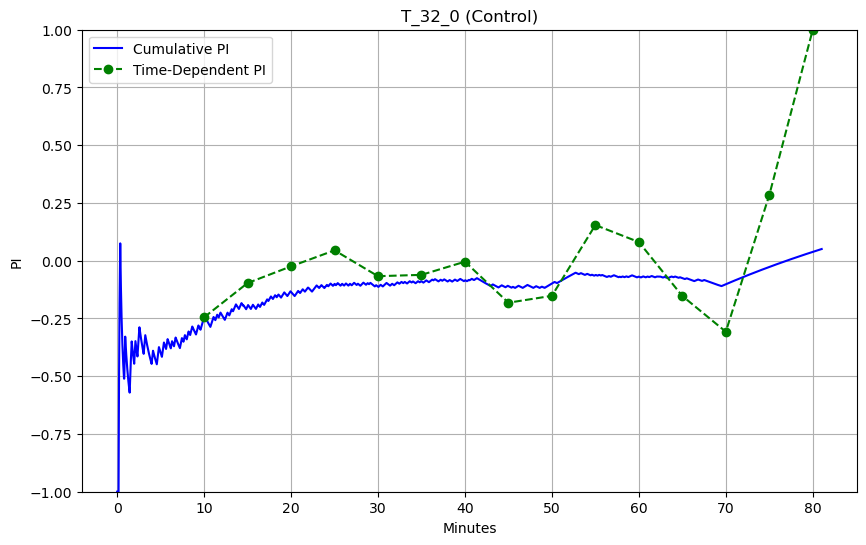

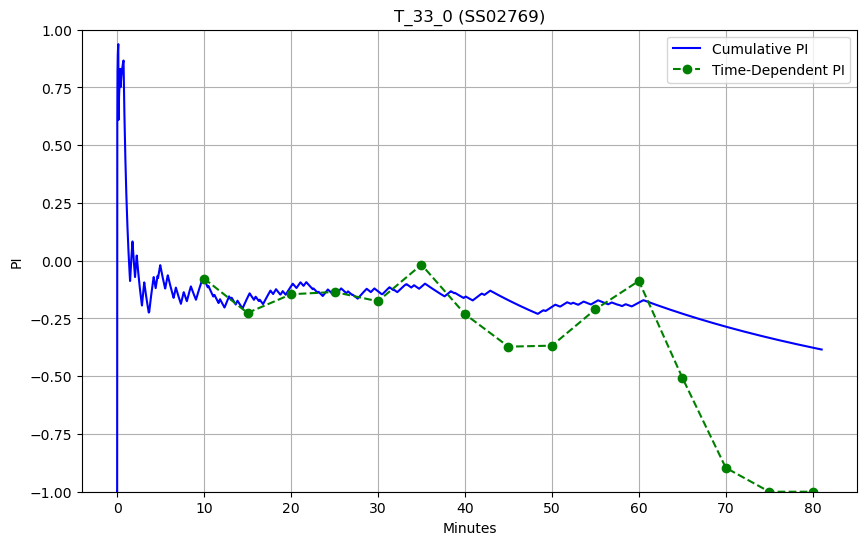

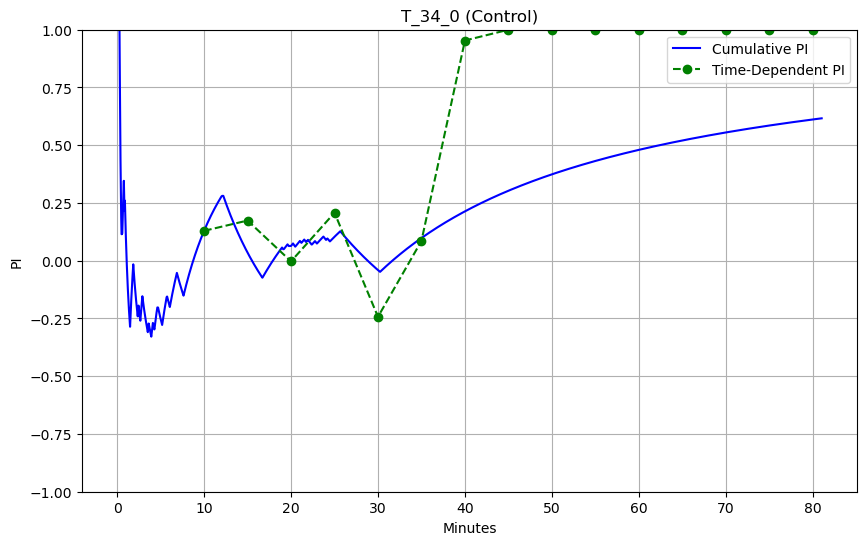

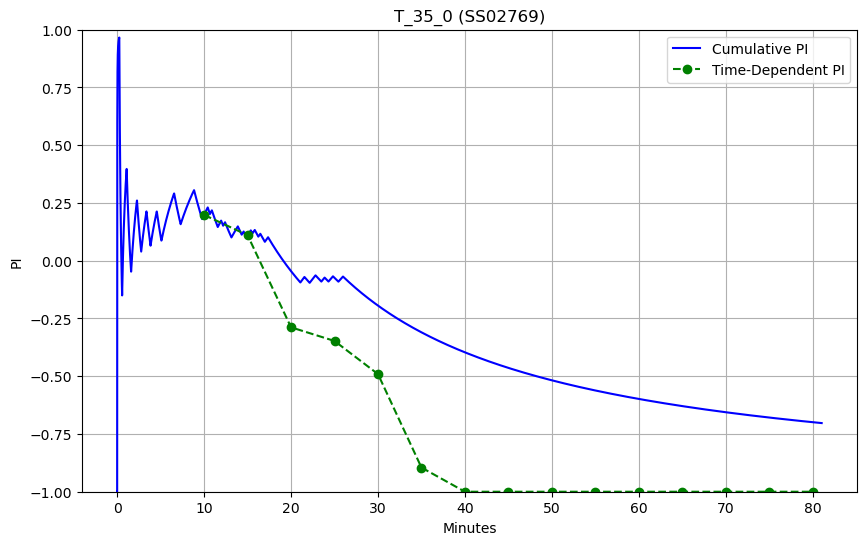

In [14]:
arena.plot_trackers_pis()

**Positional Plots:** Show the X positions of each tracker as a function of time.

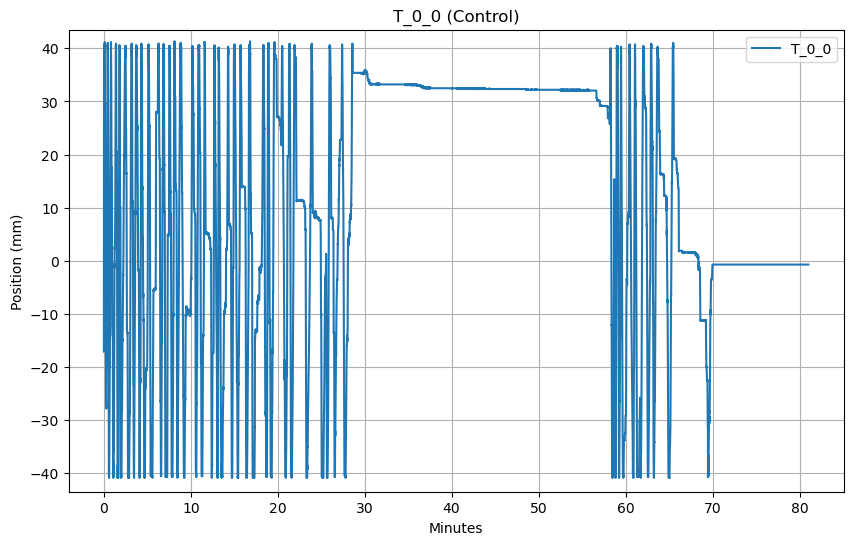

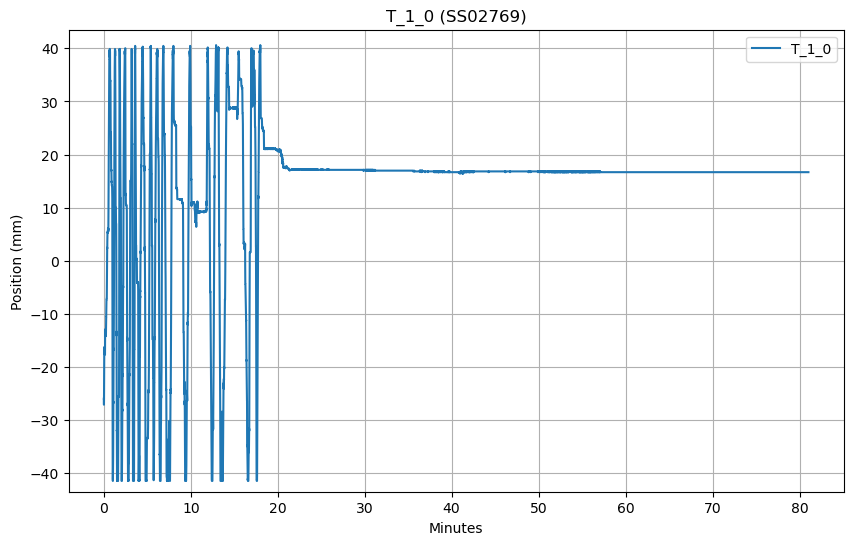

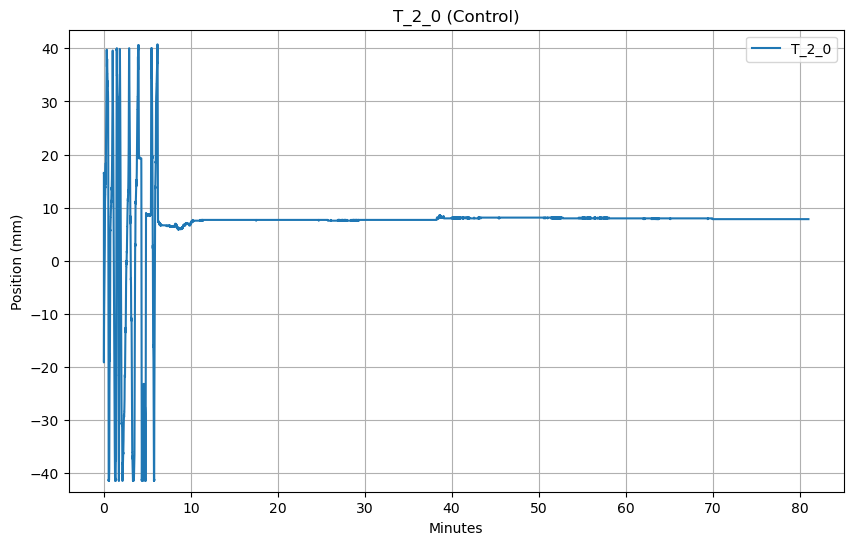

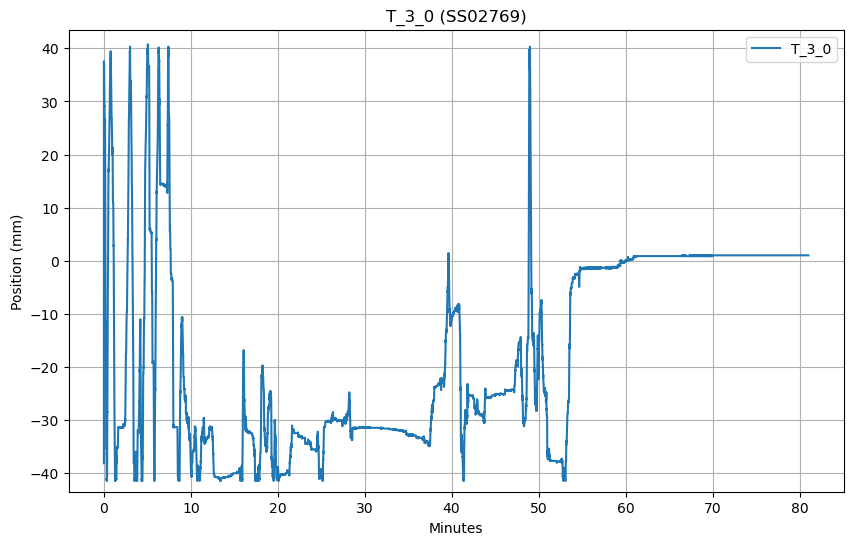

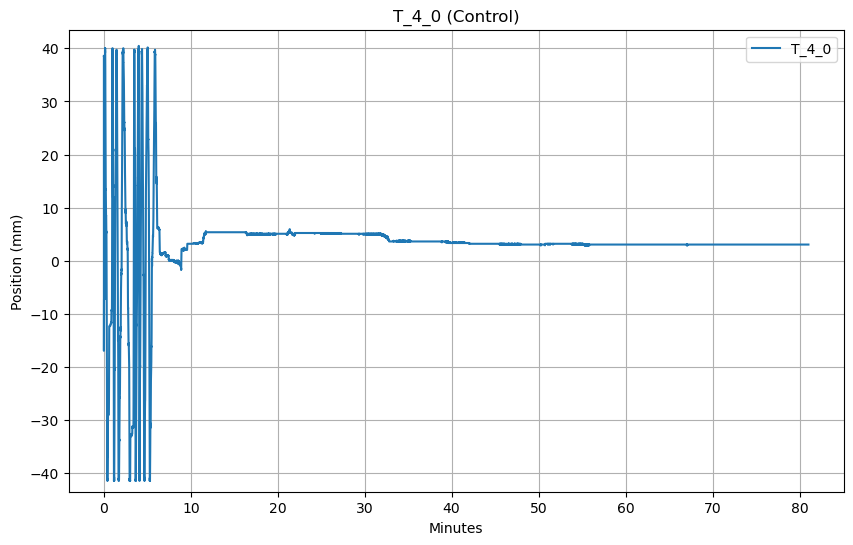

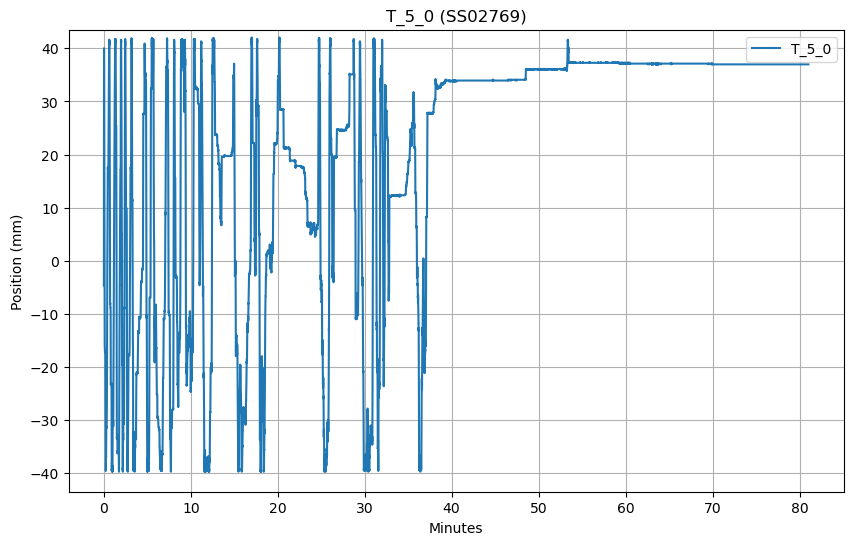

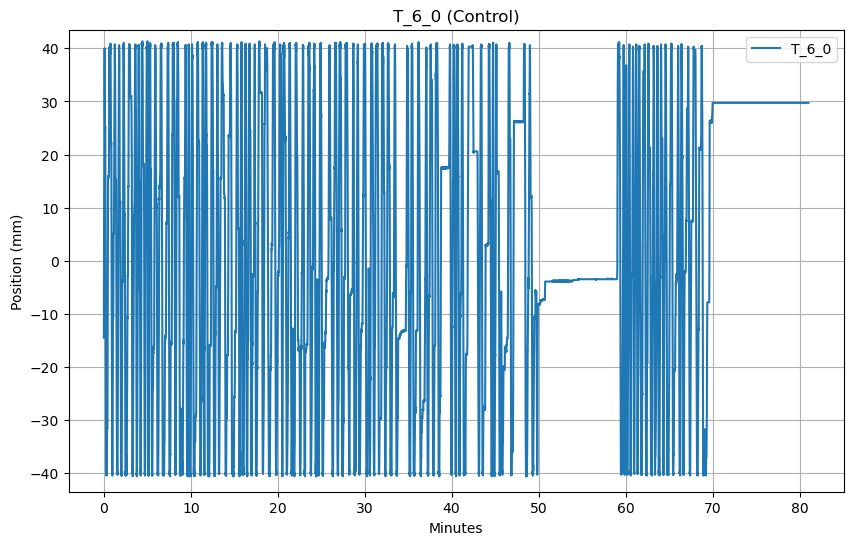

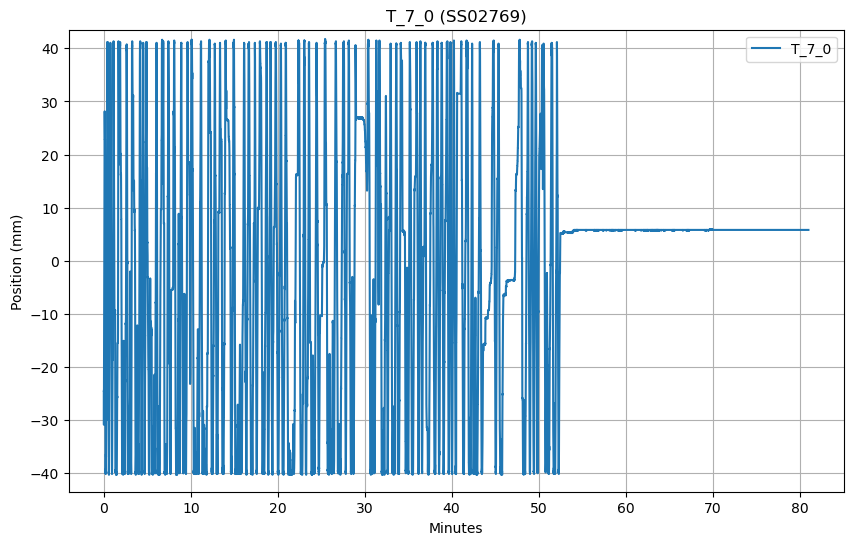

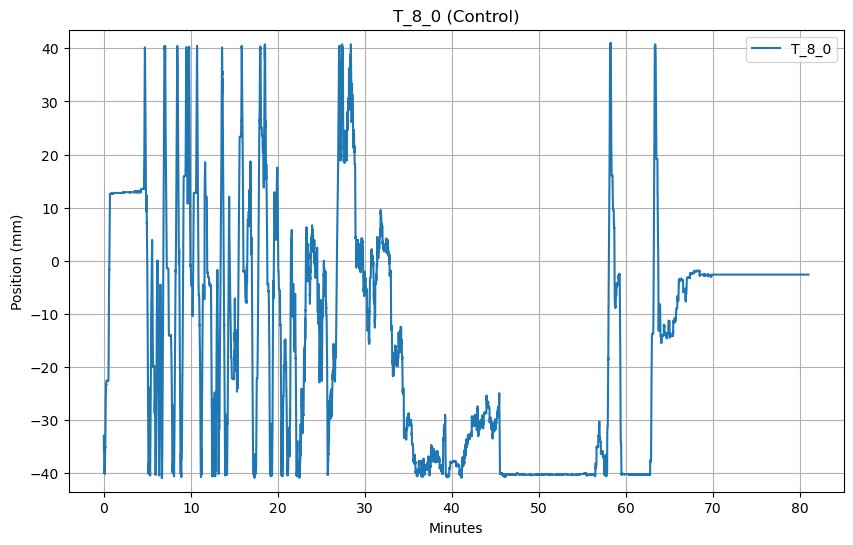

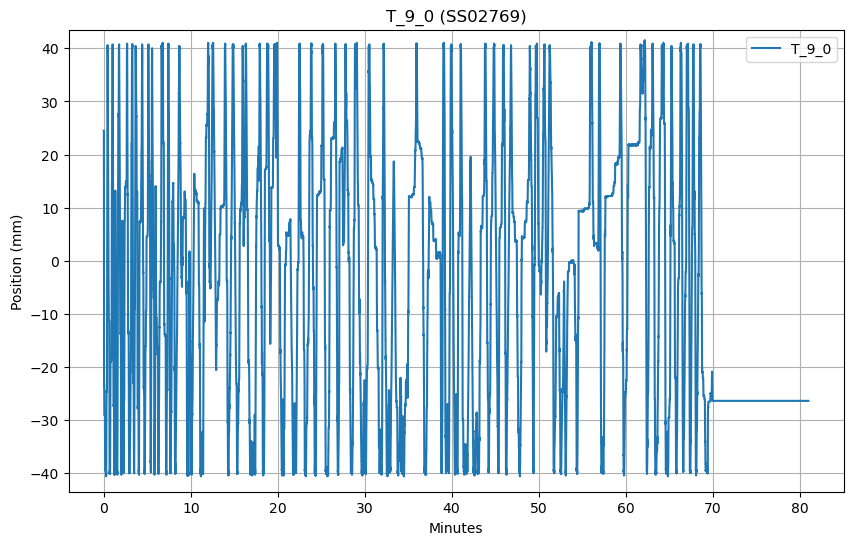

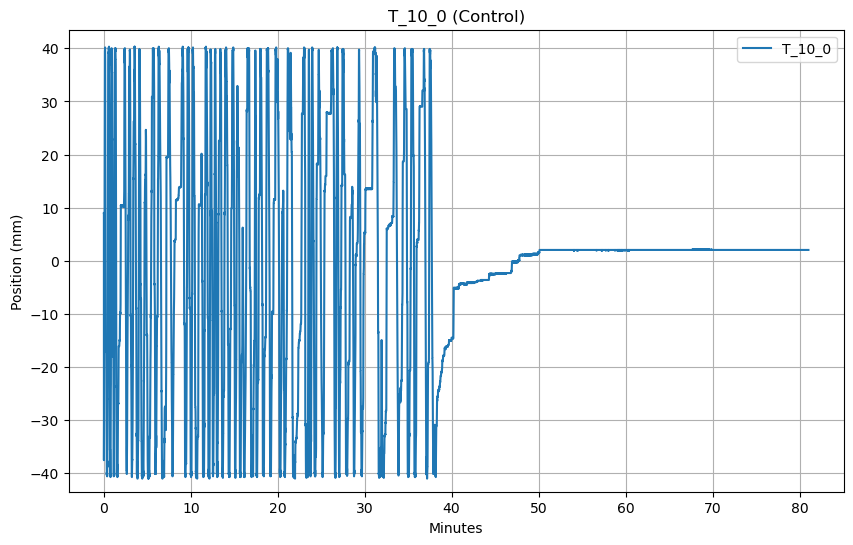

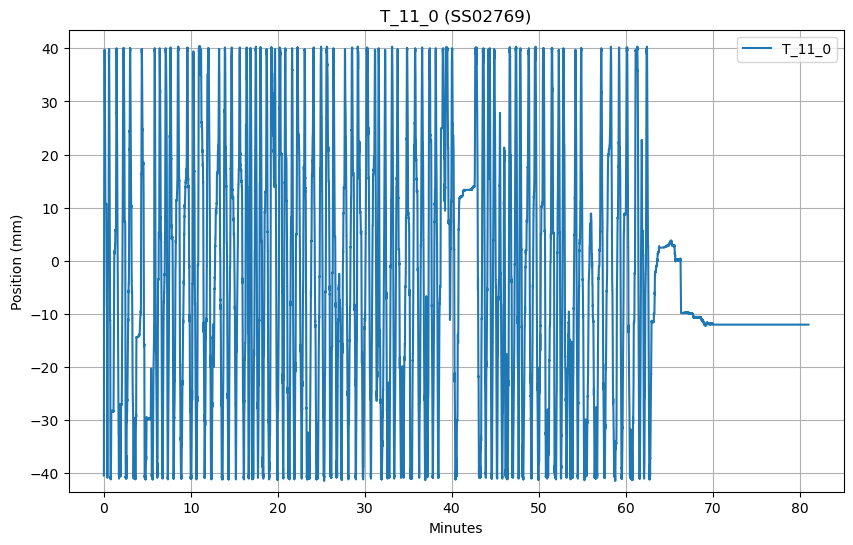

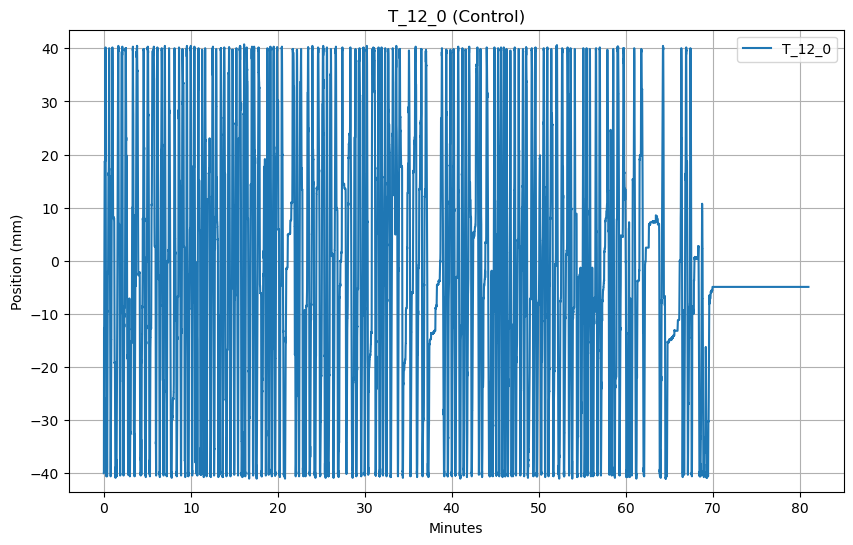

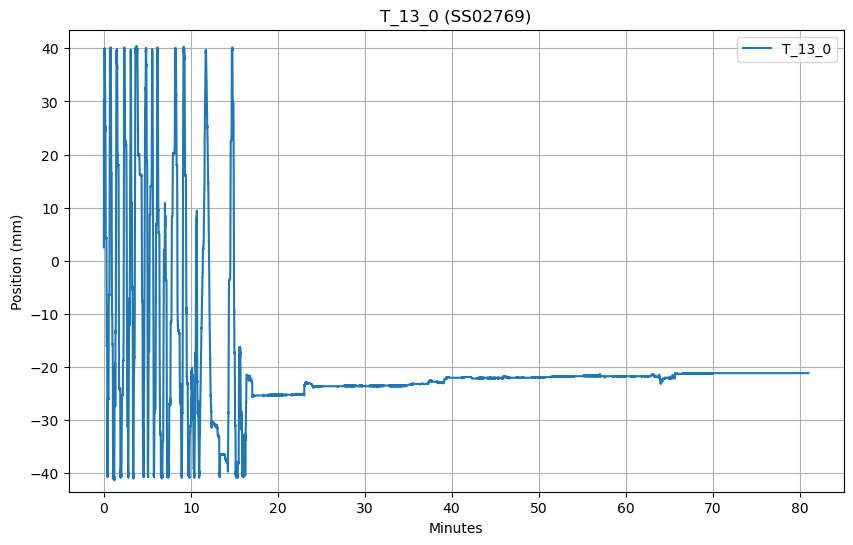

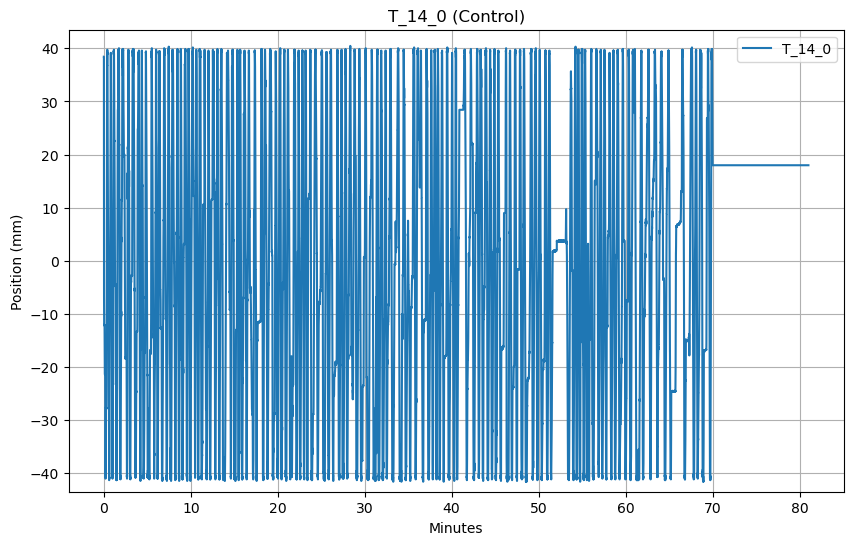

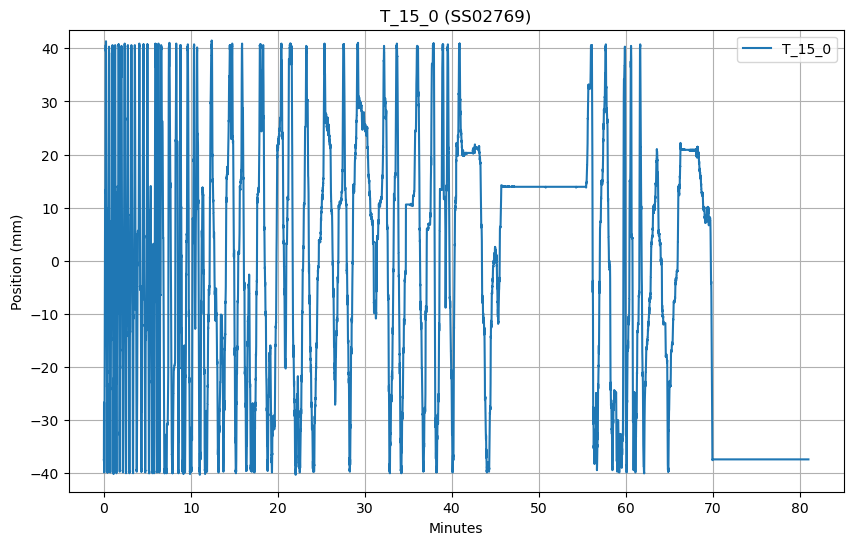

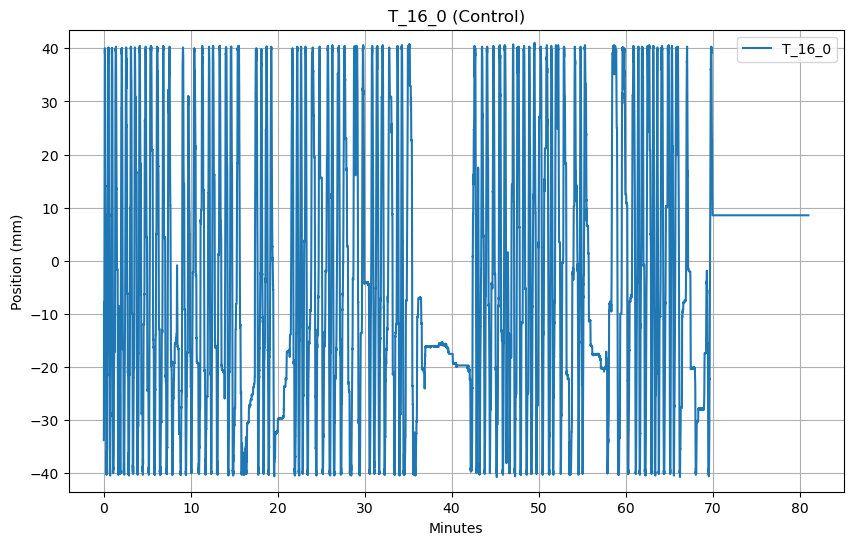

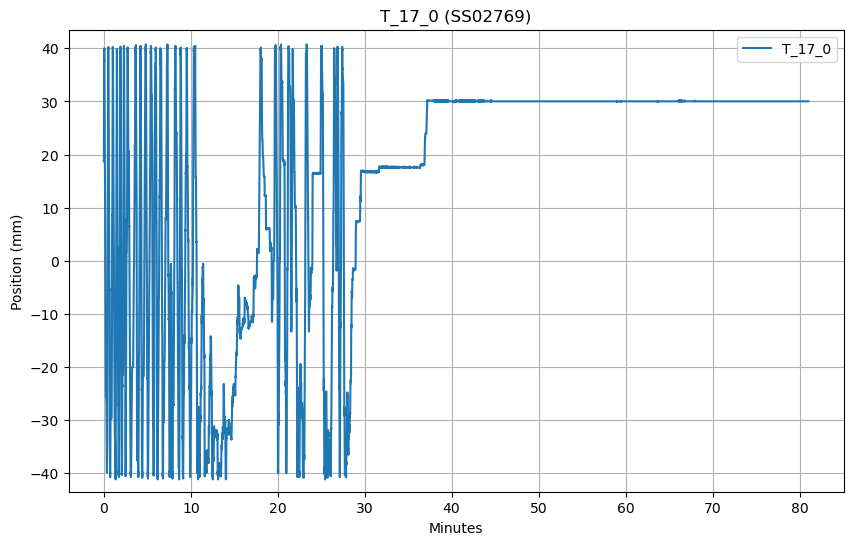

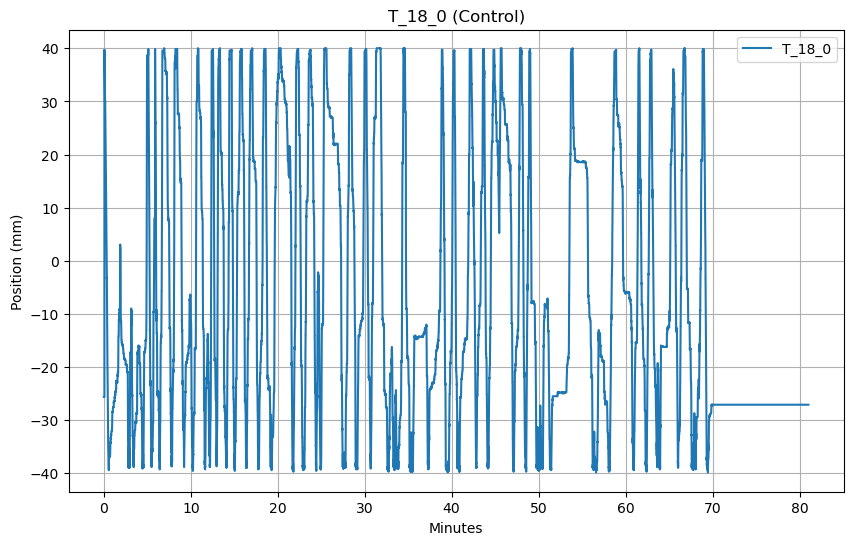

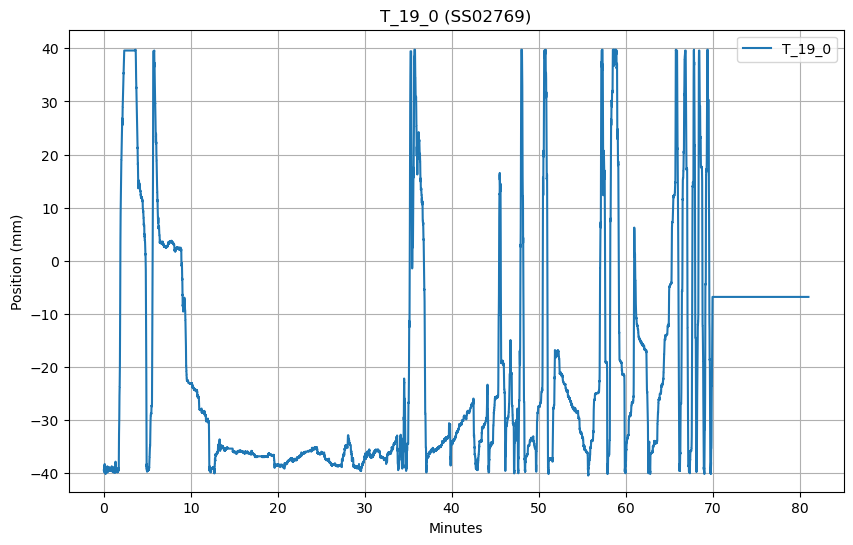

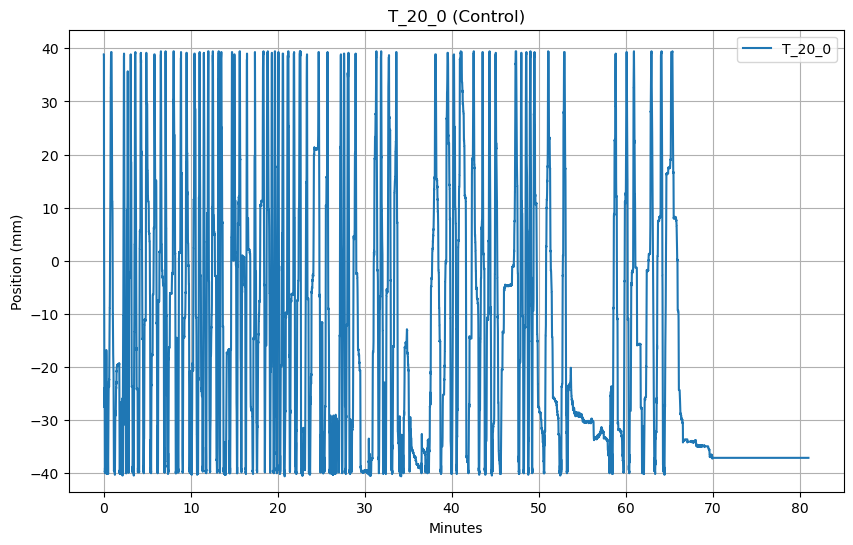

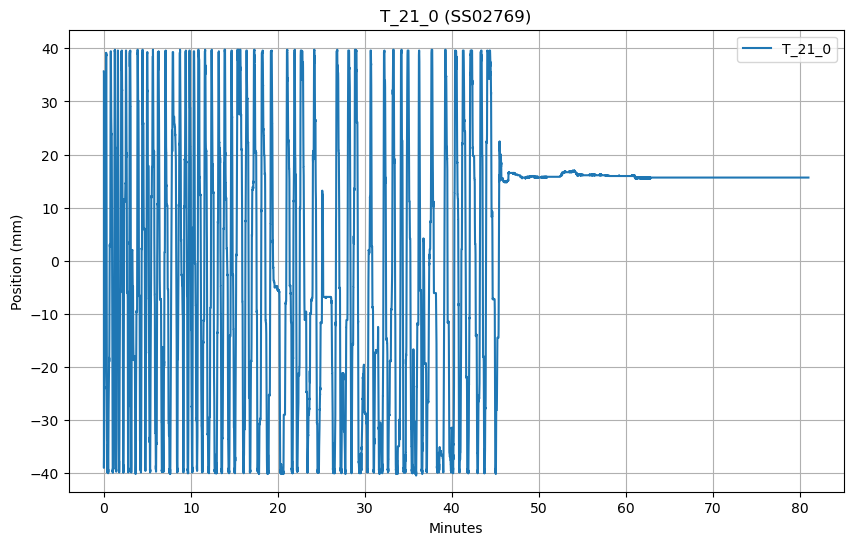

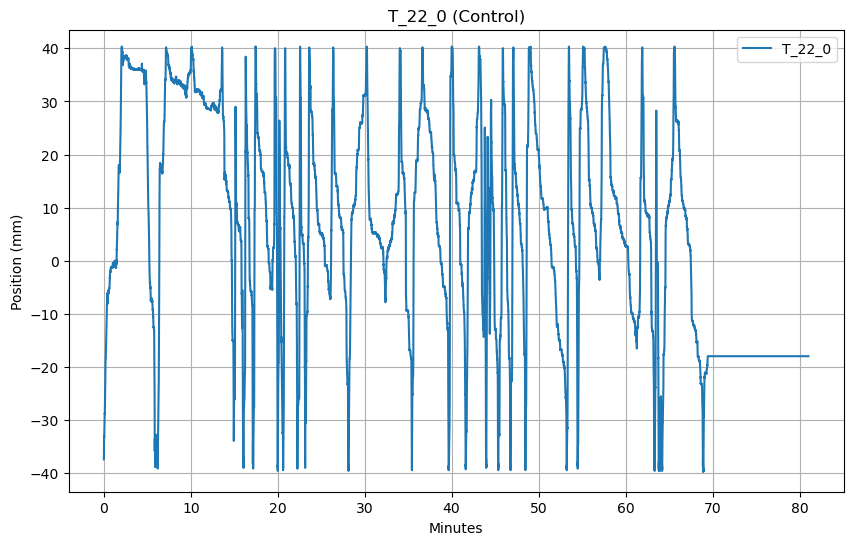

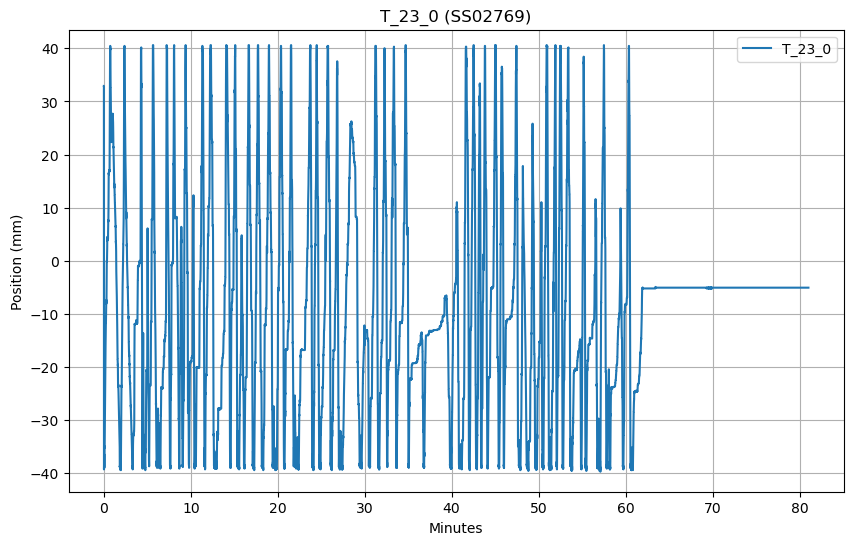

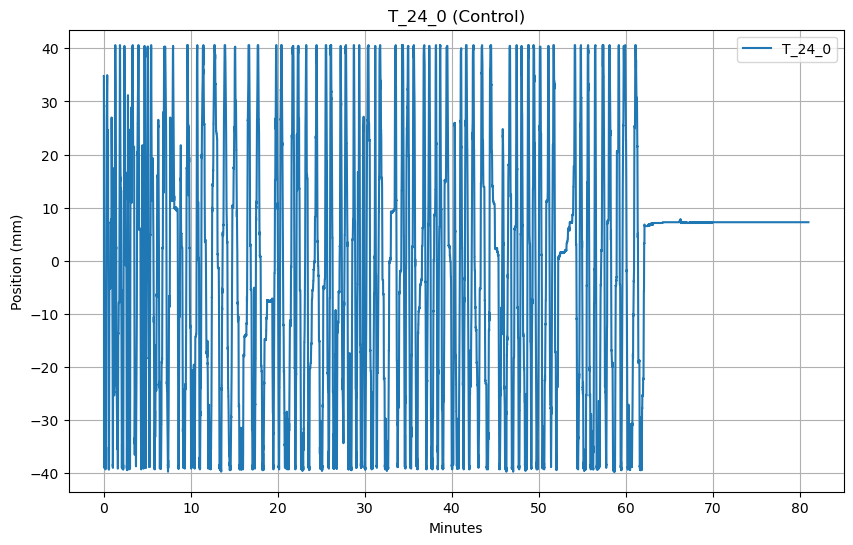

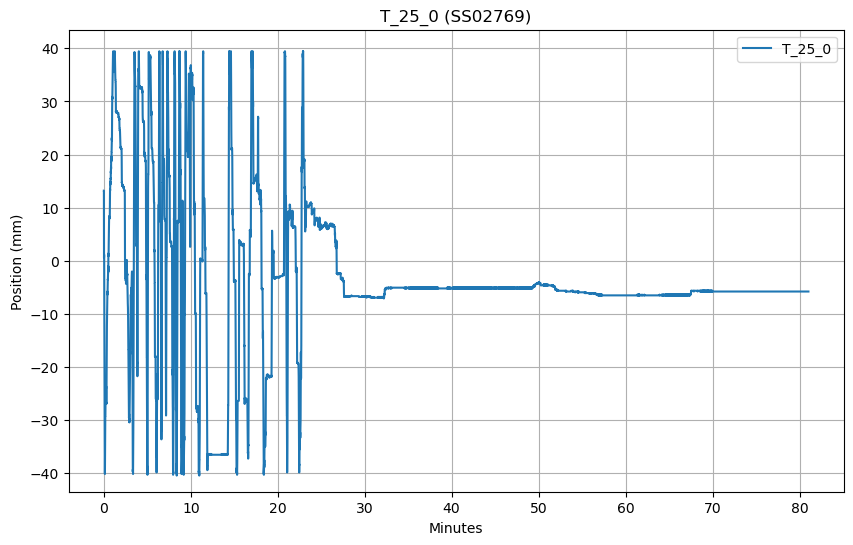

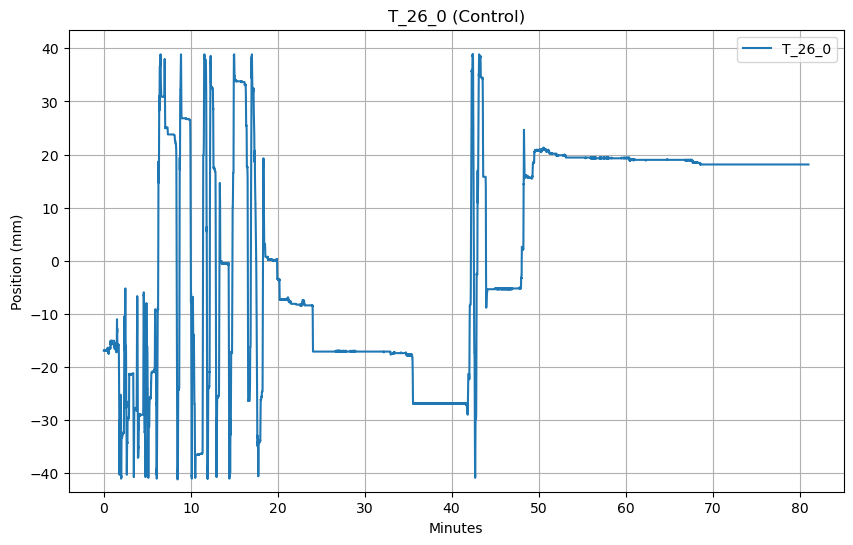

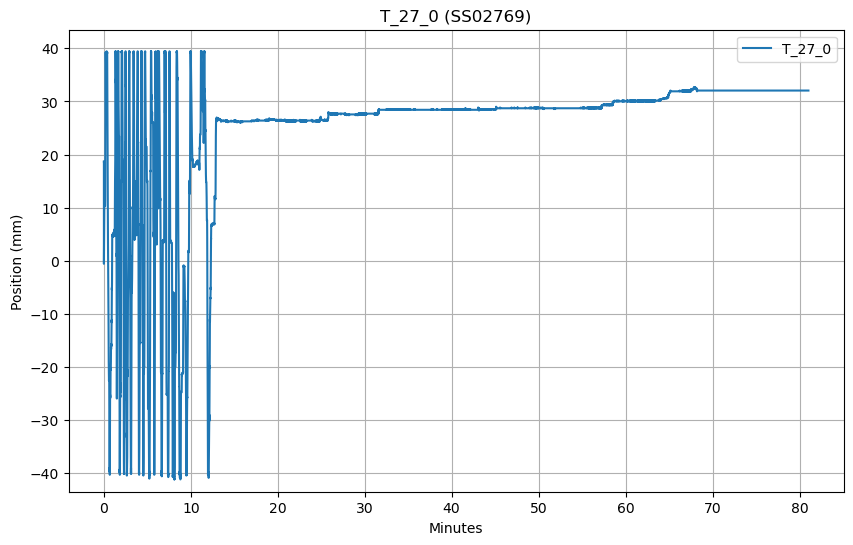

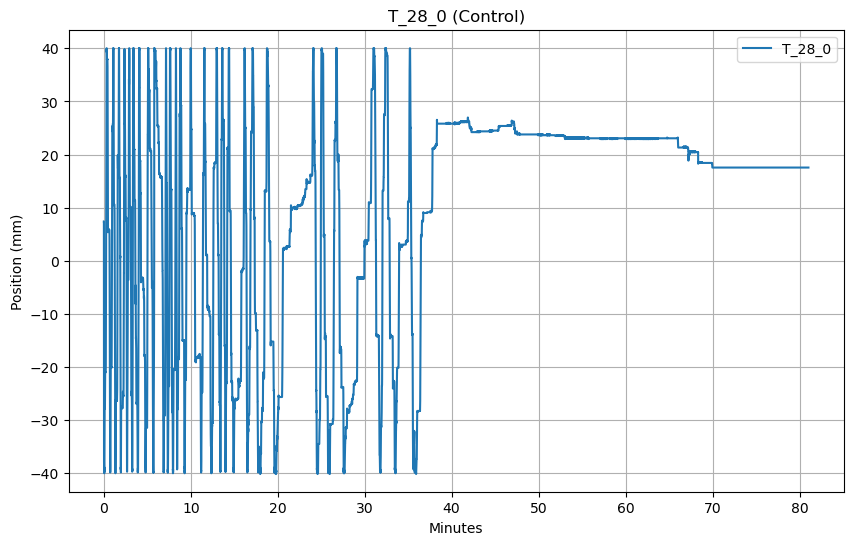

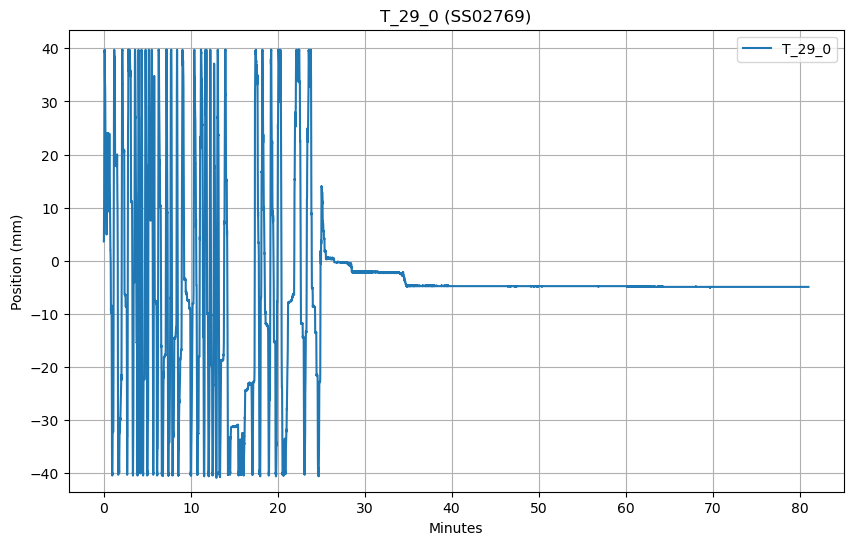

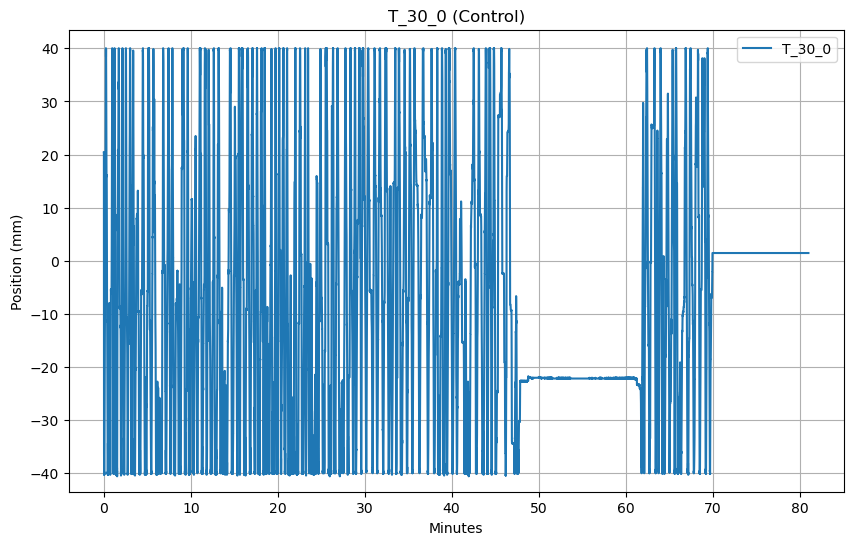

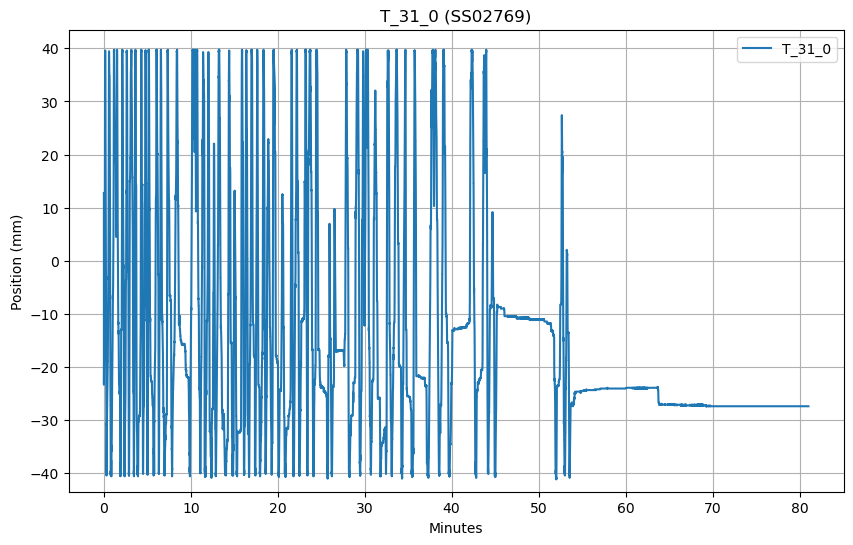

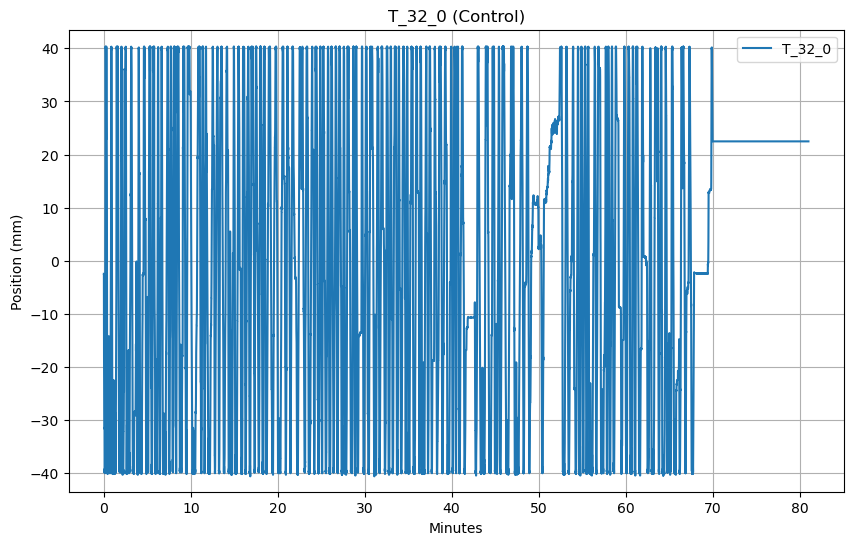

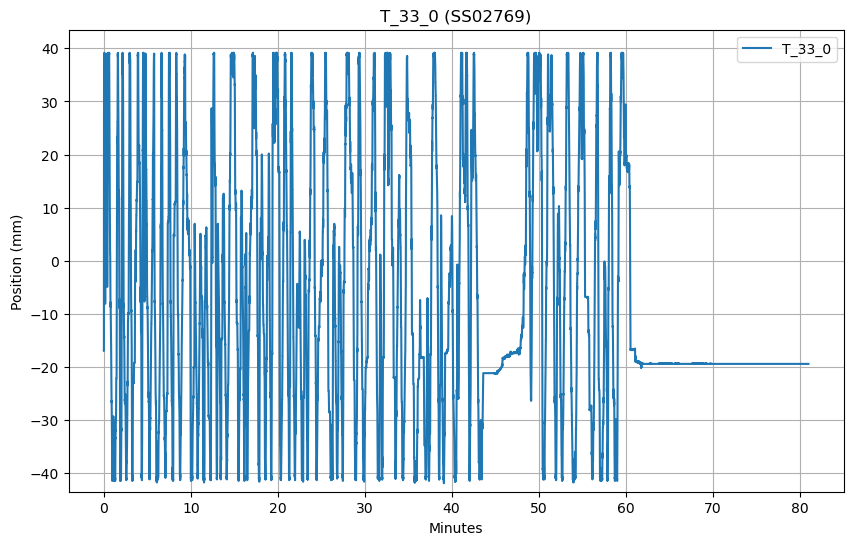

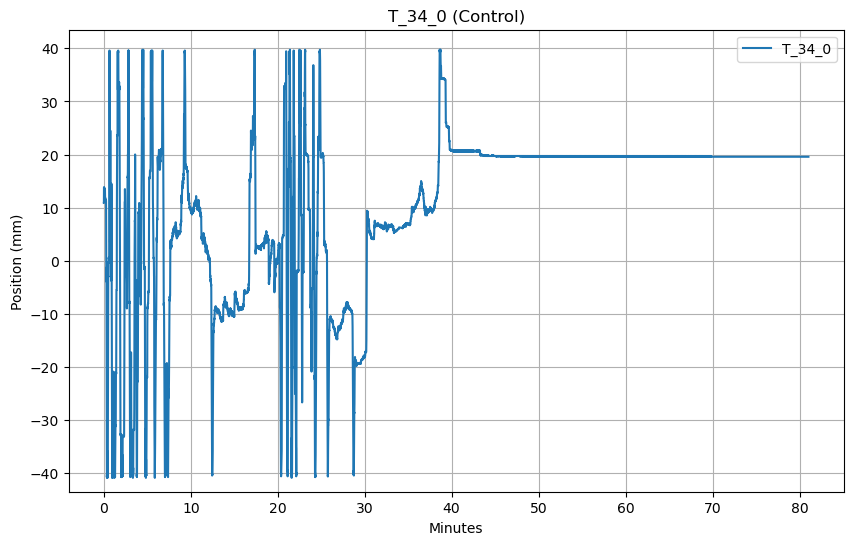

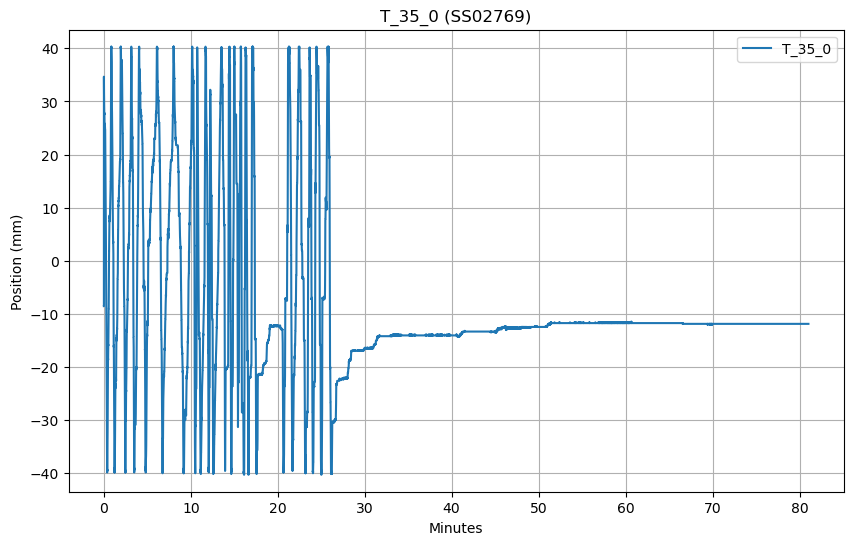

In [15]:
arena.plot_trackers_x()